# FC Temperature Dependence for pristine device
**Device:** FGT-CrPS4-hBN
**This notebook includes the figures and analyis done for Figure 2 in the main manuscript**

Both sections measure exchange bias (H_EB) and coercivity (H_C) as a function of temperature  
for Device 4 (FGT/CrPS4/hBN stack) after field cooling at ±8 T or +8 T
and the stack FGT/CrPS4 for 8T field cooling.
---

In [15]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, str(Path().resolve().parent))
from scripts.data_loader import (
    load_h5, load_txt, get_file_list,
    offset_and_AHE, normalize,
    coercivity_zero_crossing, exchange_bias, coercive_width,
    sort_serial, fixjump,
)
from scripts.notebook_setup import setup
setup()

PROJECT_ROOT = Path().resolve().parent
D4 = PROJECT_ROOT / 'data' / 'Device4'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[OK] Autoreload enabled
[OK] Project root (installed package): C:\Users\sadit\OneDrive - JGU\Projects\EB in FGT-OFGT_CrPS4
[OK] Matplotlib configured (Okabe-Ito palette, publication style)
Setup complete!


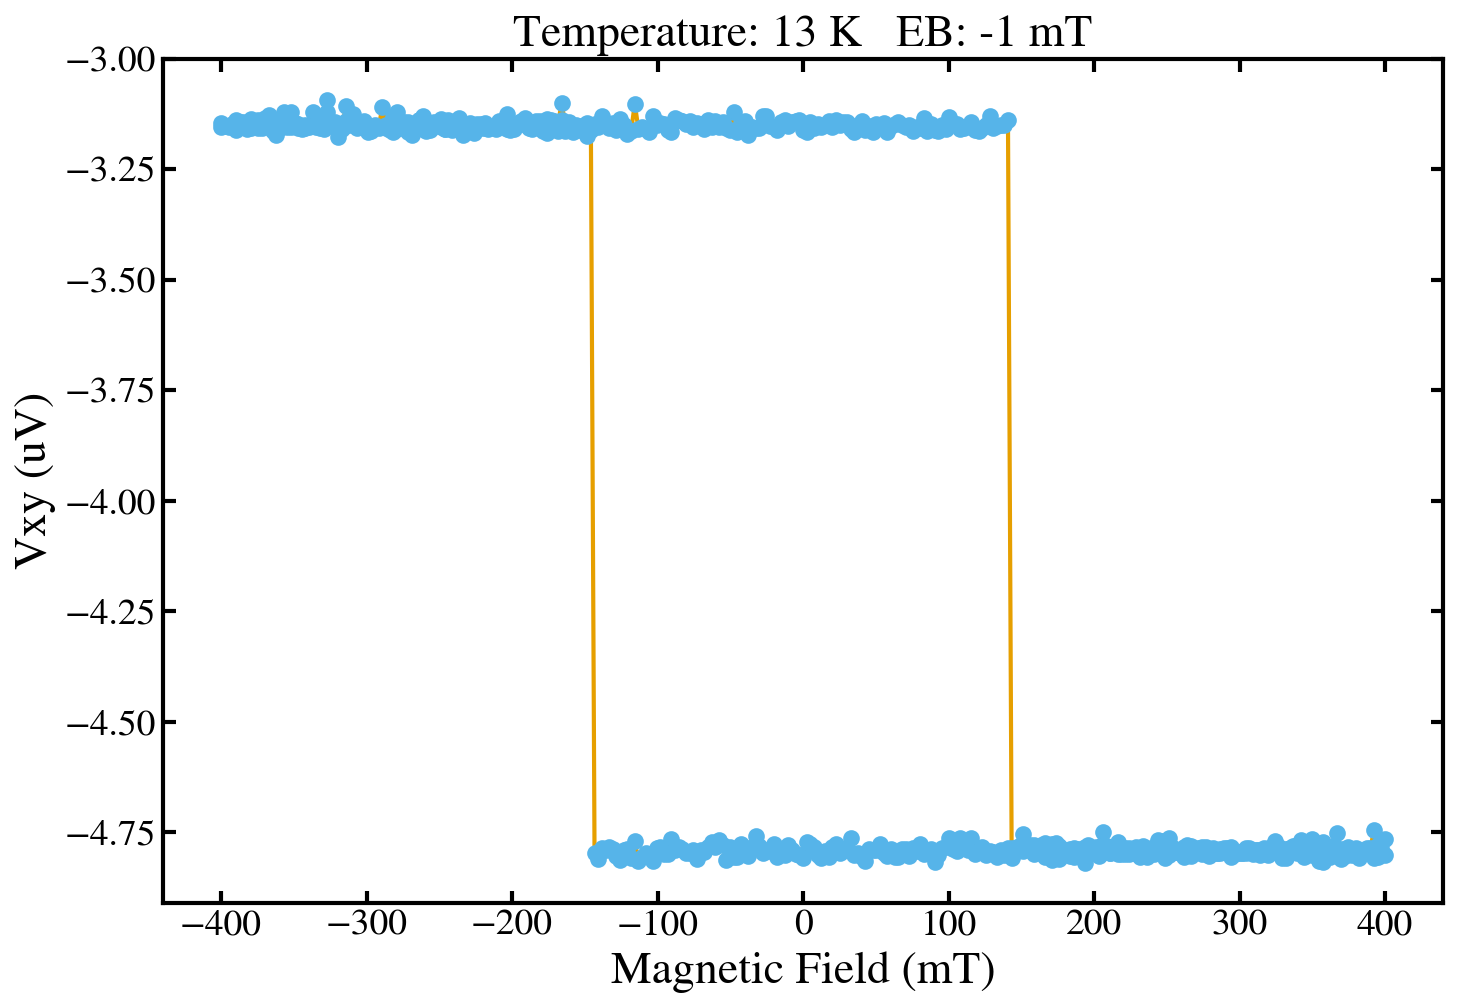

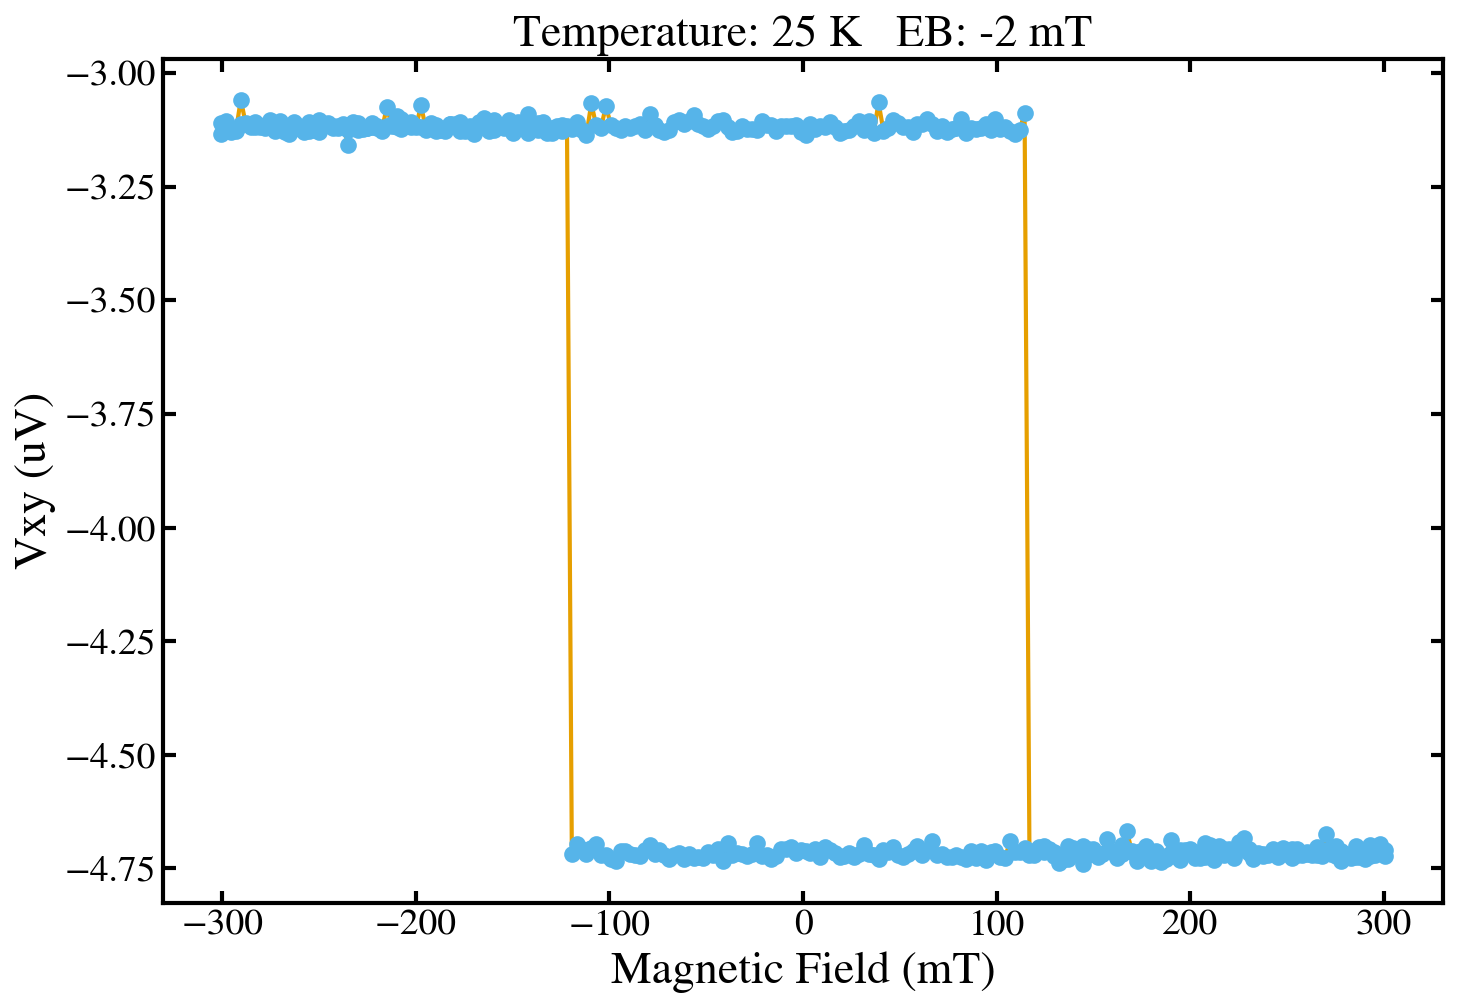

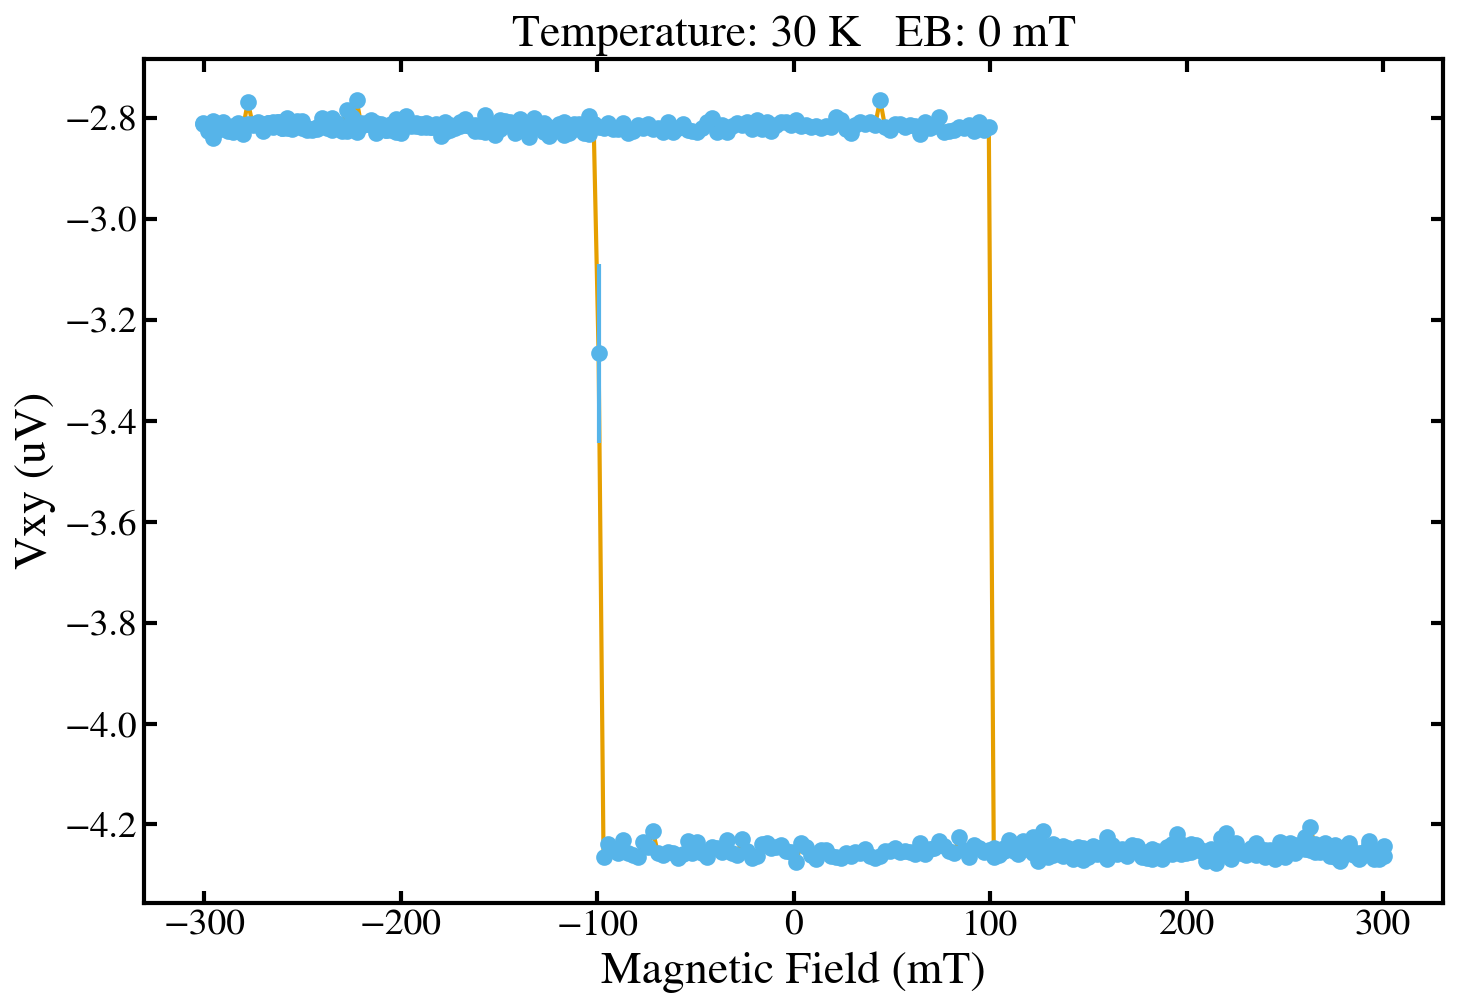

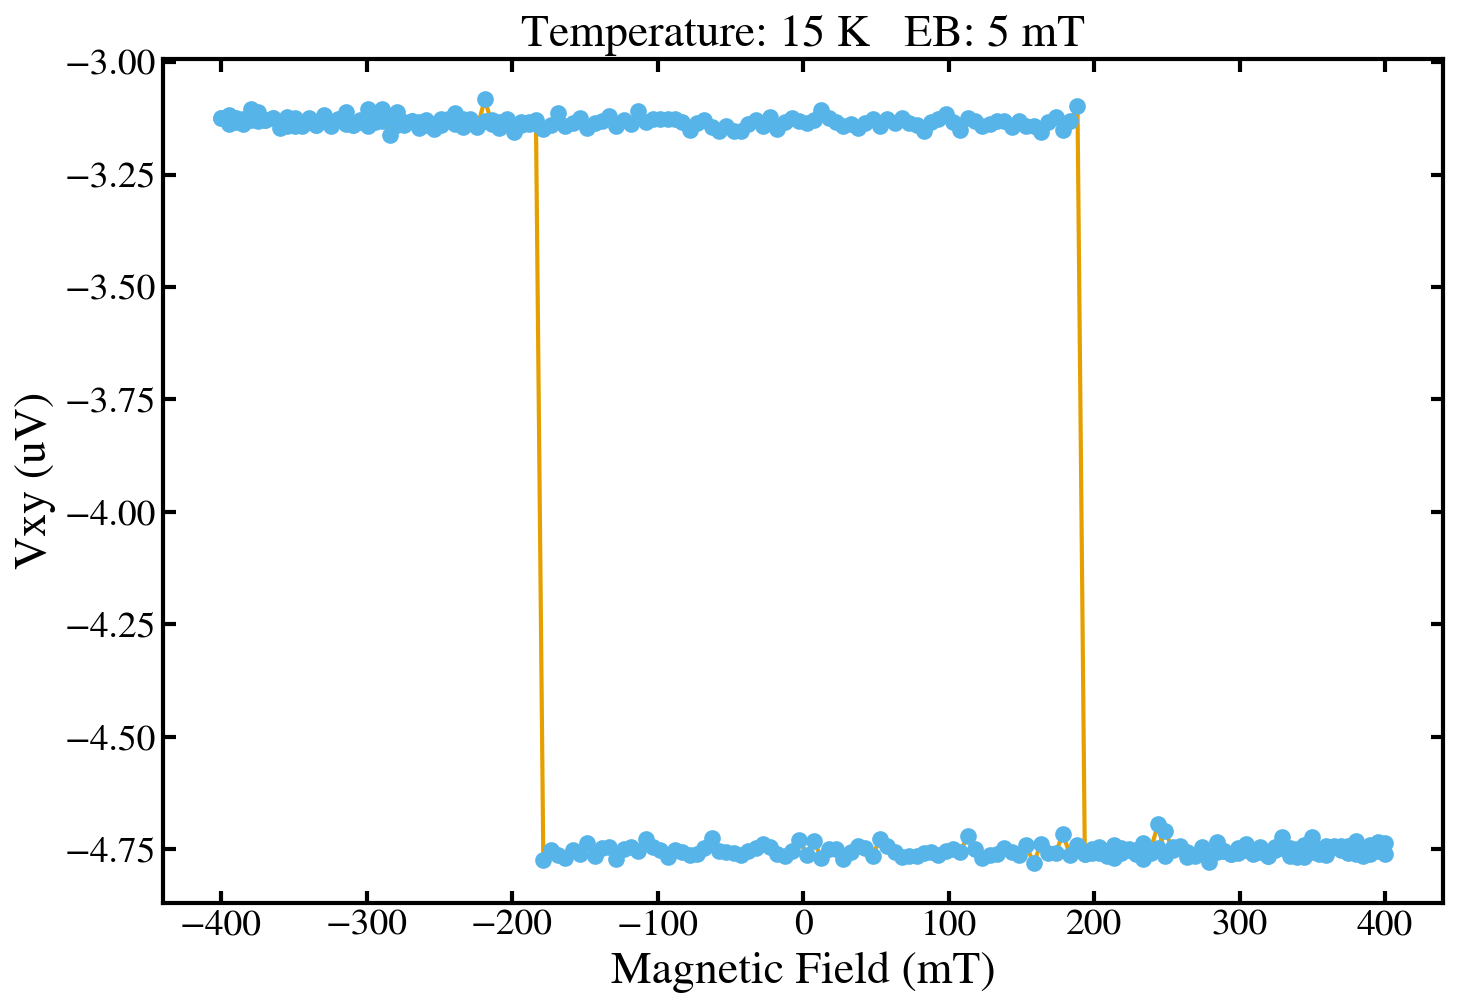

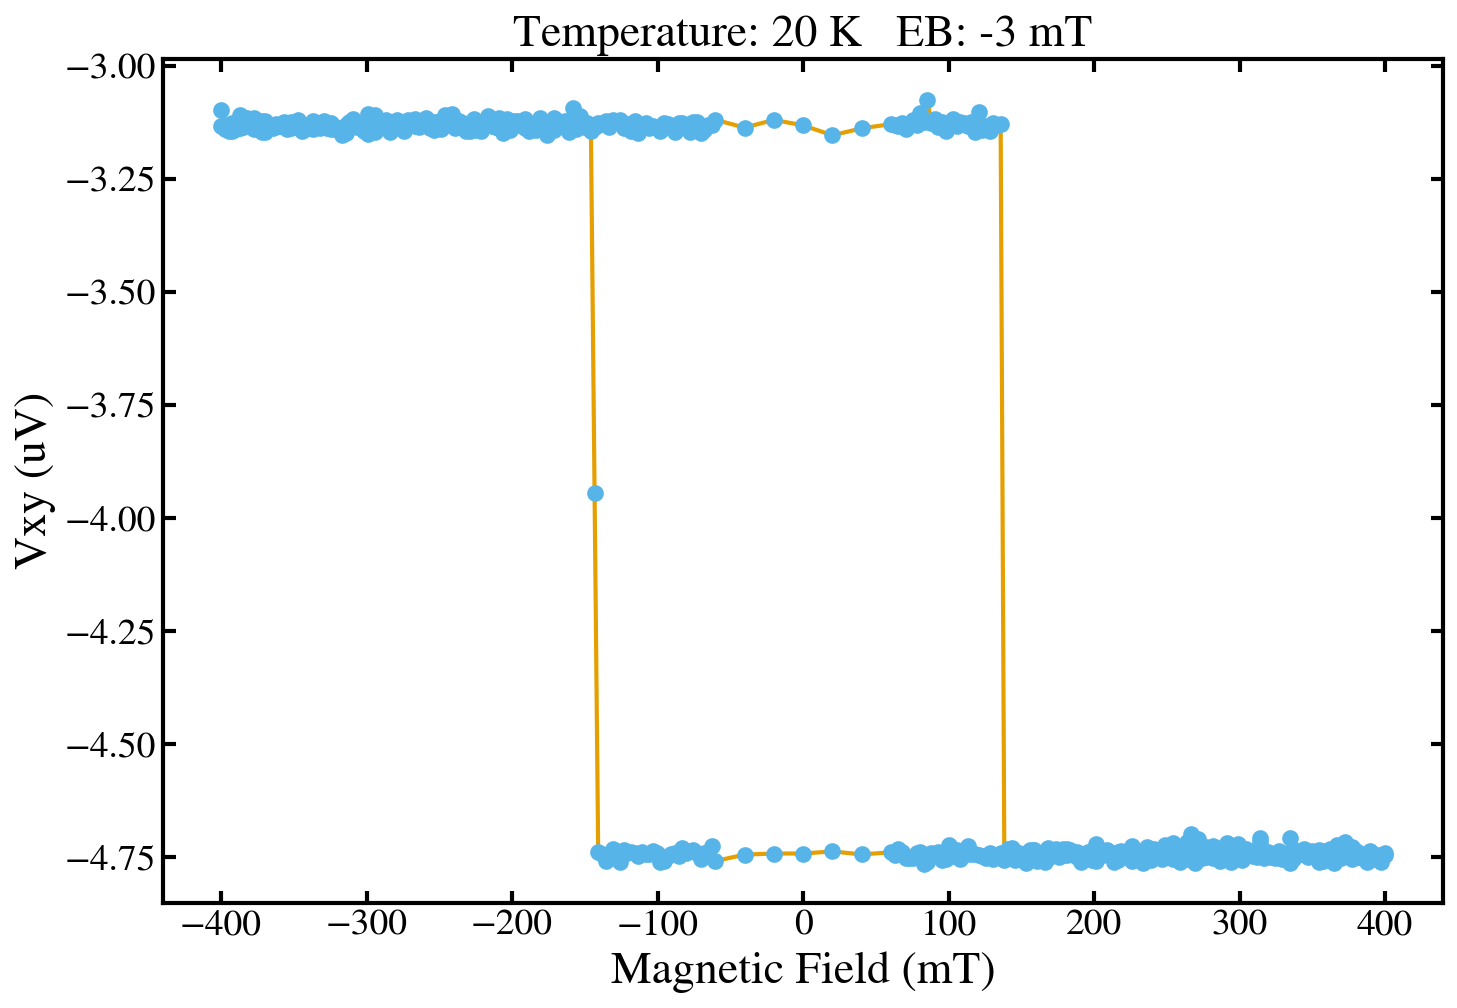

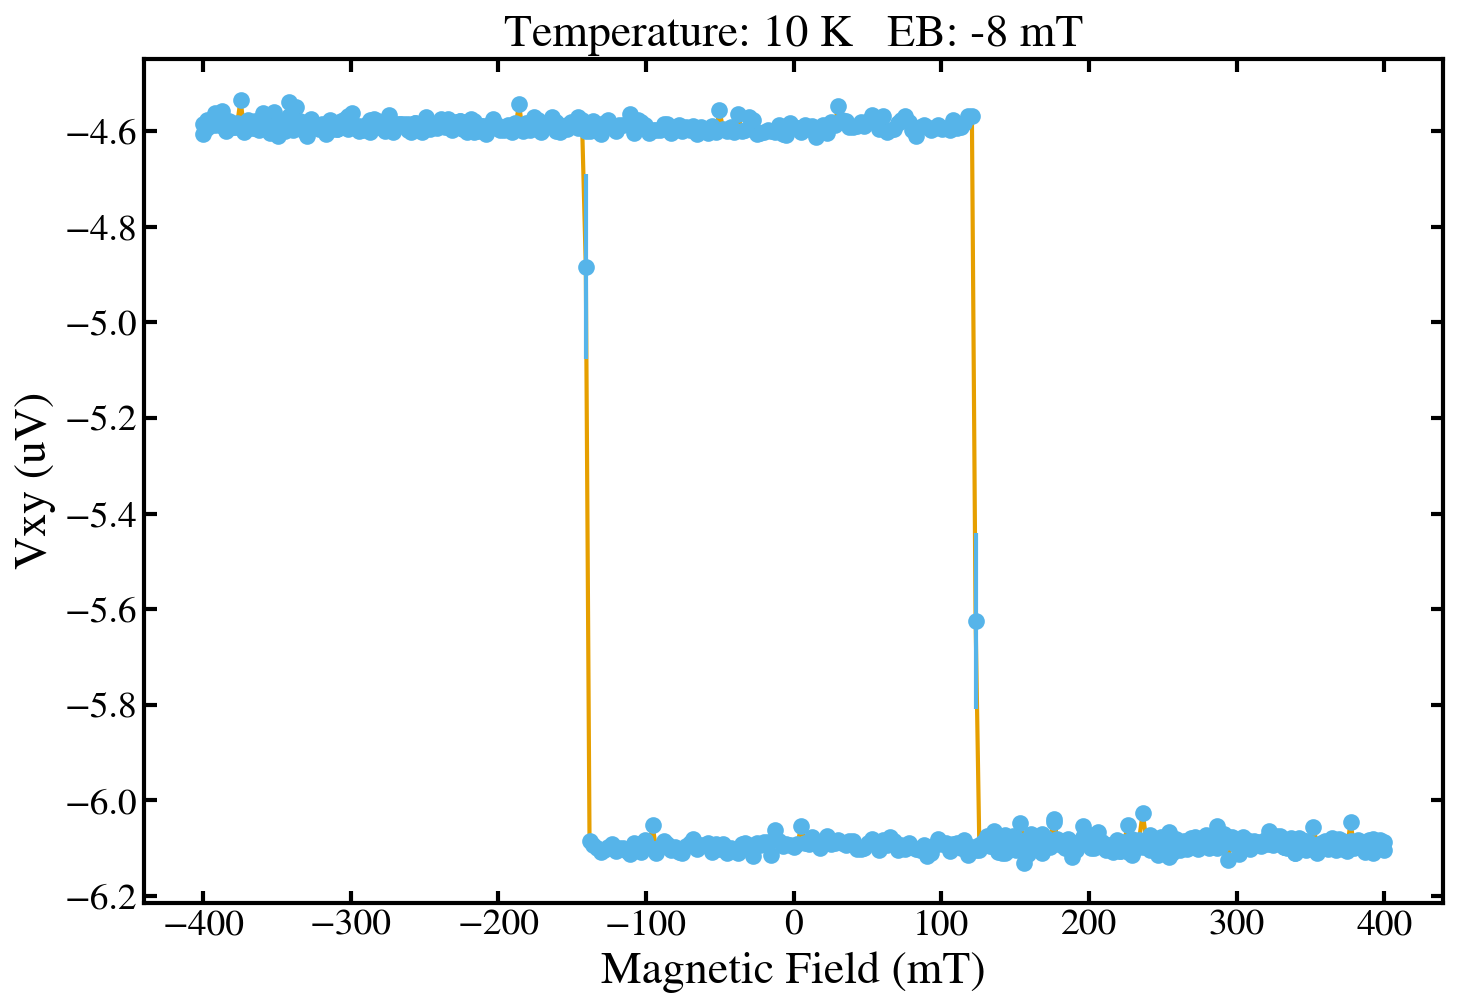

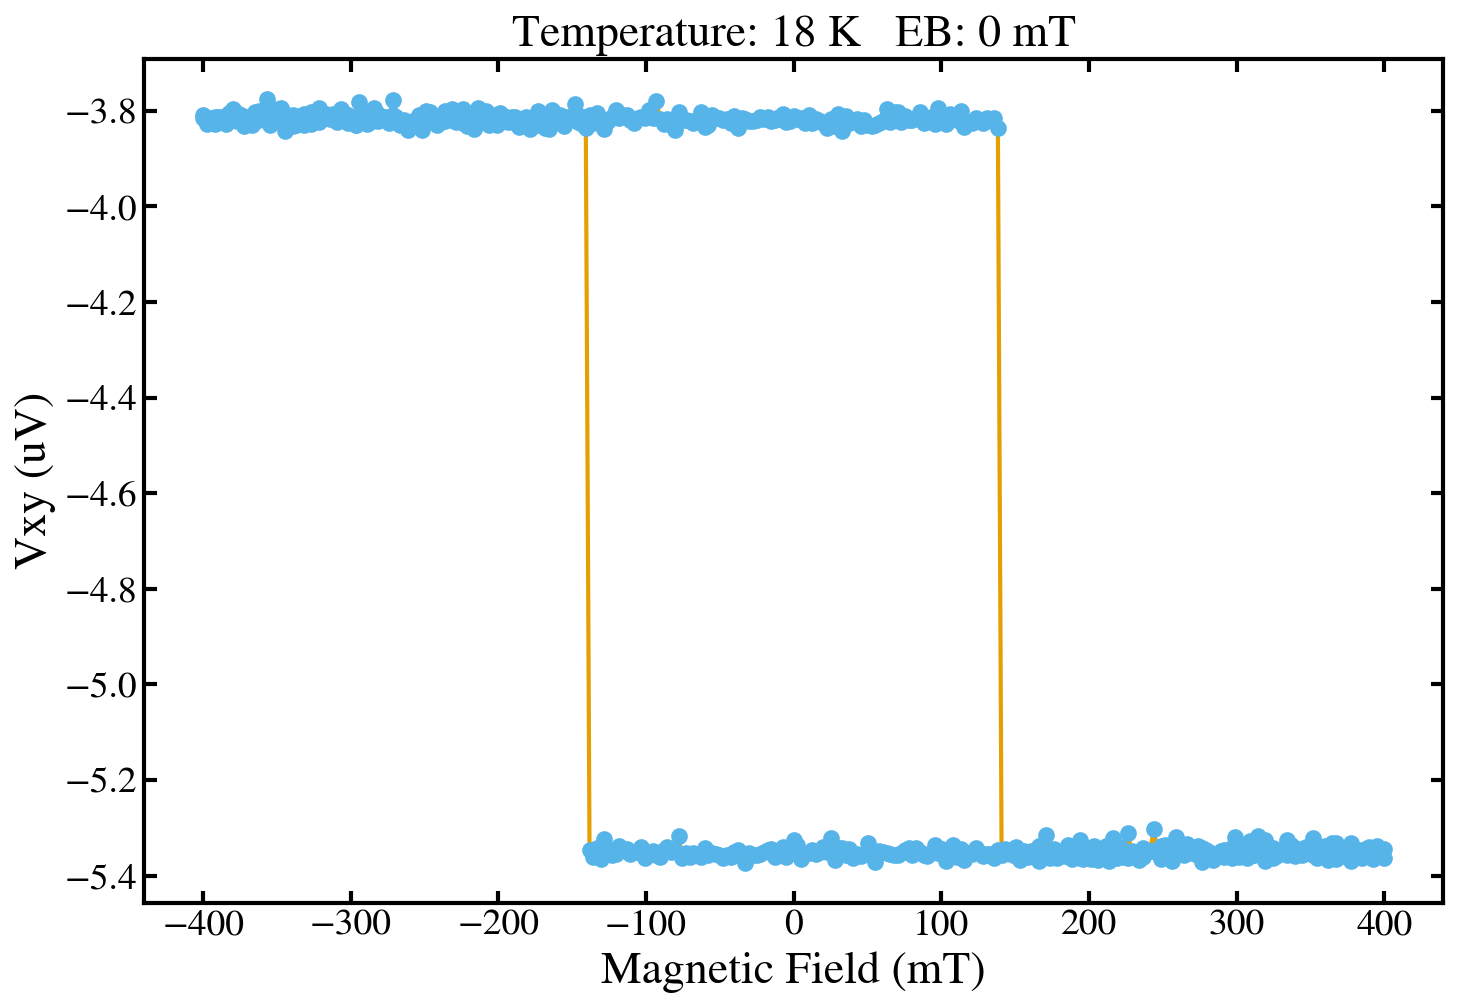

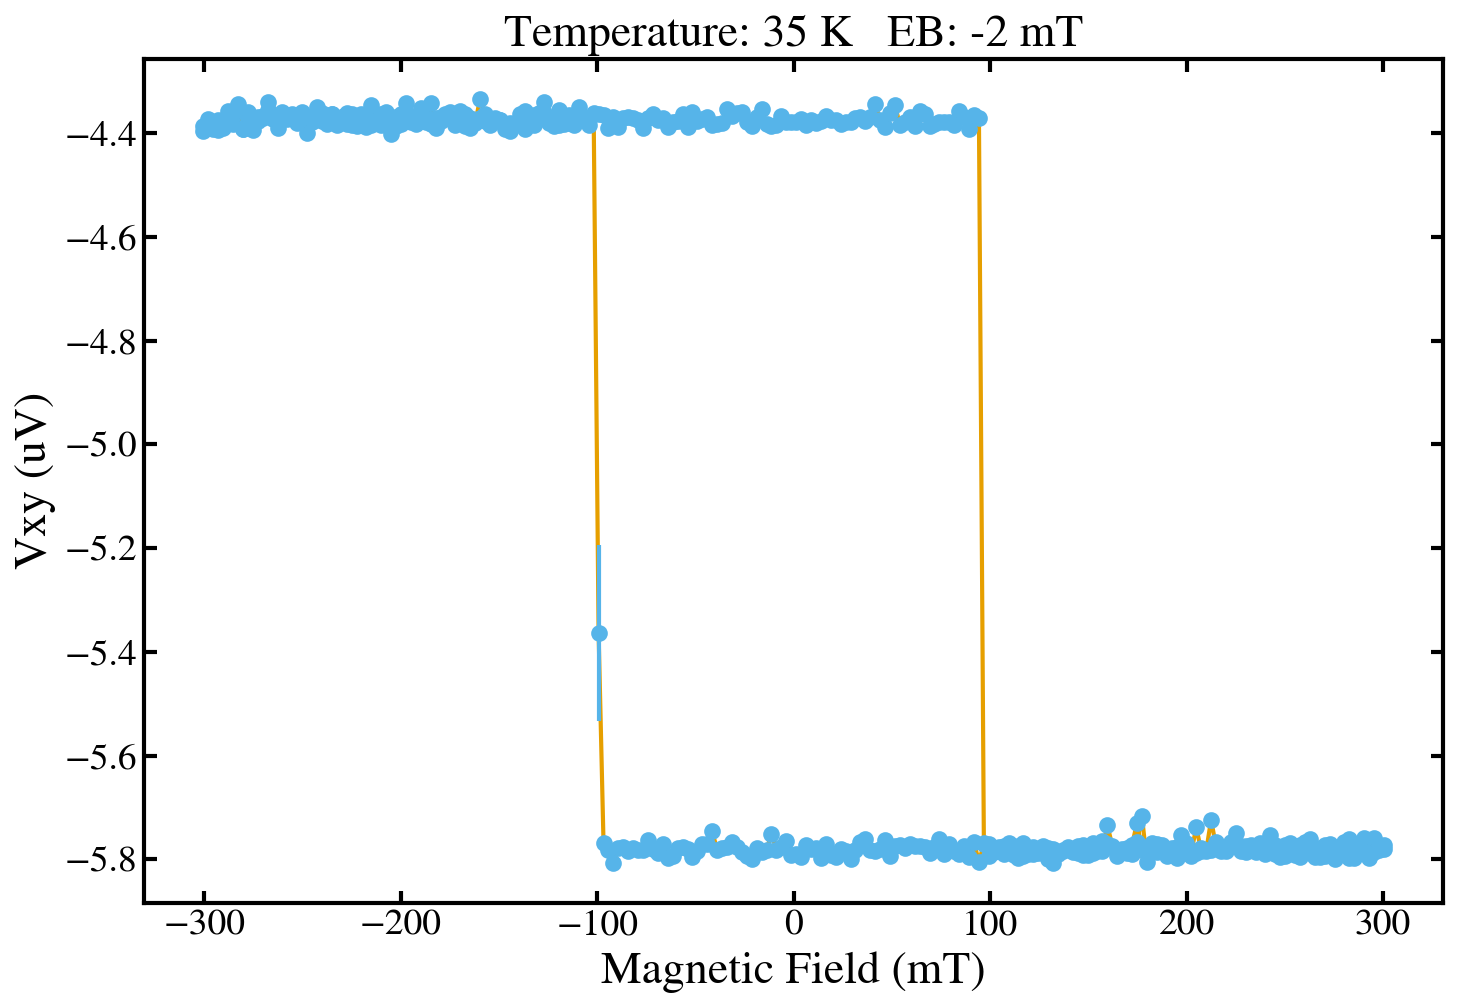

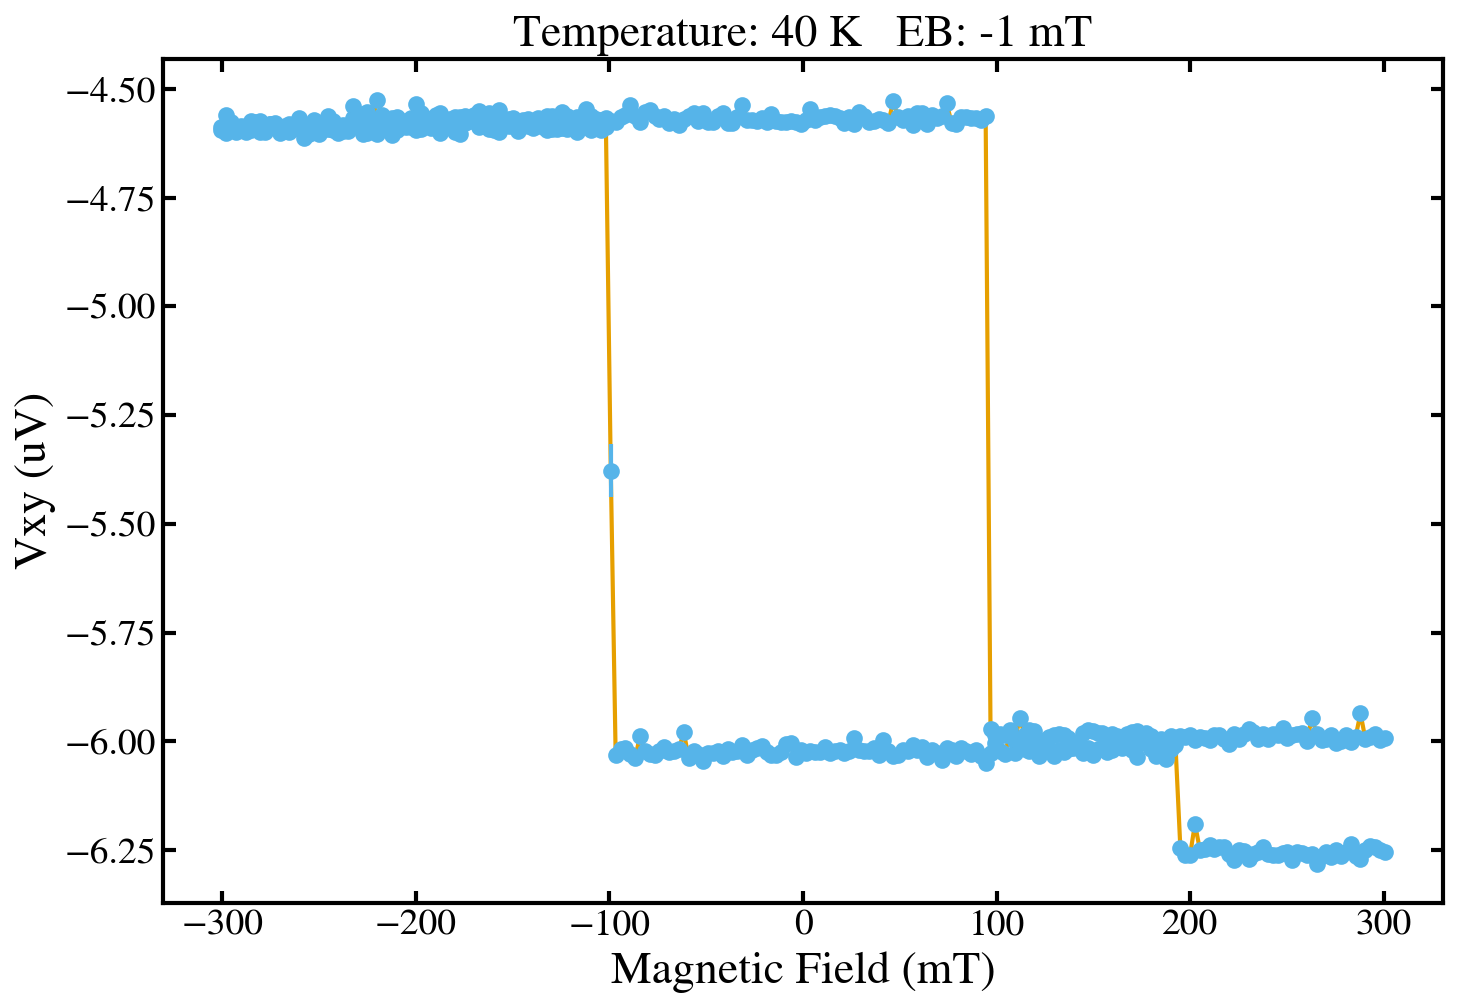

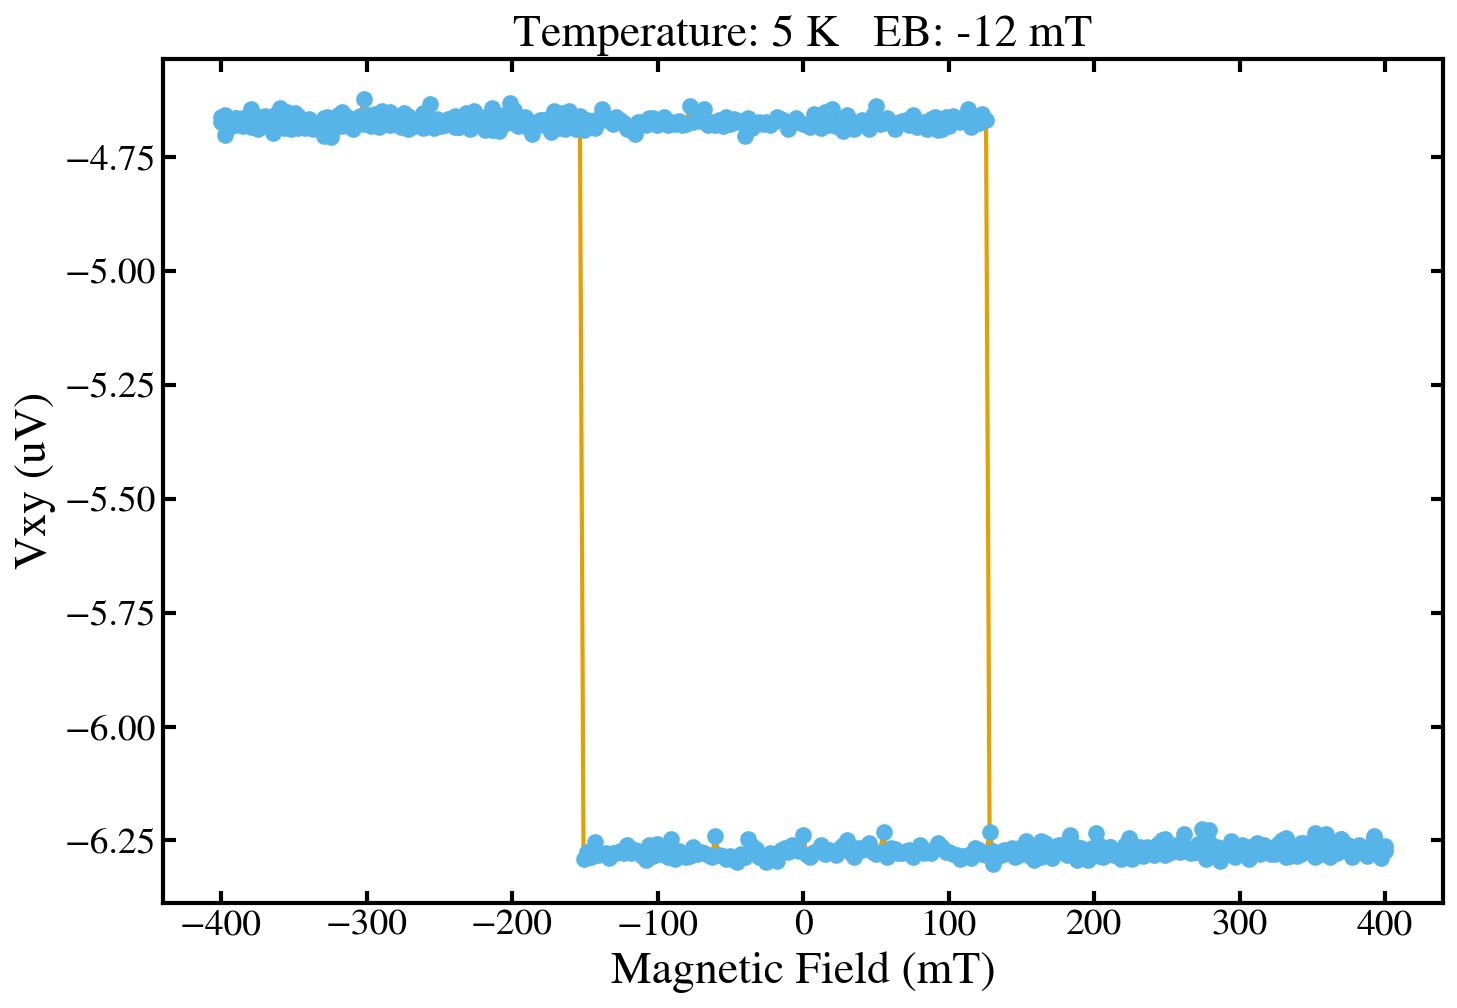

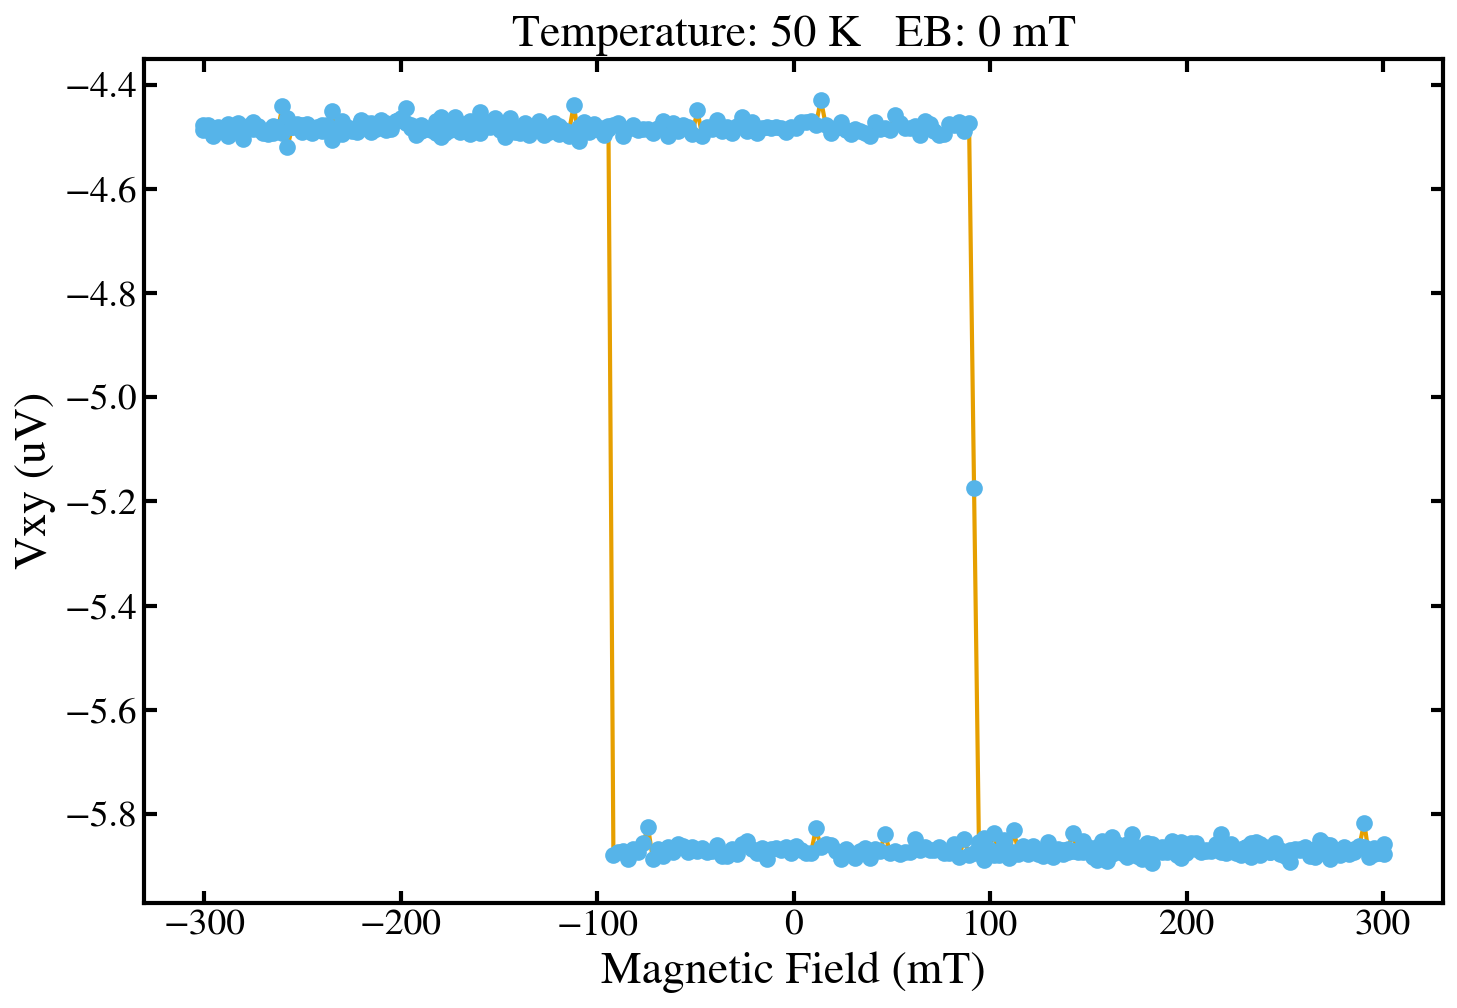

In [16]:
FOLDER_S10 = D4 / 'FC8T_FGT_CPS_hBN'

T_g10, H1_g10, H2_g10 = [], [], []
Field_g10, Vxy_norm_g10, Vxy_err_g10 = [], [], []
Vxx_g10, Vxx_err_g10 = [], []
Vahe_g10, Vahe_err_g10 = [], []
error_g10 = []

for fp in get_file_list(FOLDER_S10):
    if fp.suffix.lower() == '.h5':
        d = load_h5(fp, channel_xy=2, P=None)  # P=None → auto-detect
    else:
        d = load_txt(fp, skiprows=15, vxy_col='Voltage-2 (V)', trim=None)

    F       = d['Field']
    Sig     = d['Vxy']
    Sig_err = d['Vxy_err']
    ref     = d['Vxx']
    Rxx_err = d['Vxx_err']
    T       = d['T']

    offset, _, Vahe, Vahe_err = offset_and_AHE(Sig)
    Sig_norm = normalize(Sig, offset, Vahe)
    HC_neg, HC_pos = coercivity_zero_crossing(F, Sig_norm)
    HEB = exchange_bias(HC_neg, HC_pos)

    errf = round(abs(float(F[0]) - float(F[1])) / 2, 1)

    T_g10.append(T)
    H1_g10.append(HC_neg)
    H2_g10.append(HC_pos)
    Field_g10.append(F)
    Vxy_norm_g10.append(Sig_norm)
    Vxy_err_g10.append(Sig_err)
    Vxx_g10.append(ref)
    Vxx_err_g10.append(Rxx_err)
    Vahe_g10.append(float(Vahe))
    Vahe_err_g10.append(float(Vahe_err))
    error_g10.append(errf)

    # F1a — Vxy diagnostic
    plt.figure()
    plt.xlabel('Magnetic Field (mT)')
    plt.ylabel('Vxy (uV)')
    plt.title(f'Temperature: {T} K   EB: {int(HEB)} mT')
    plt.plot(F, Sig)
    plt.errorbar(F, Sig, Sig_err, fmt='o')
    plt.tight_layout()
    plt.show()


T_g10    = np.array(T_g10)
H1_g10   = np.array(H1_g10)
H2_g10   = np.array(H2_g10)
HEB_g10  = (H1_g10 + H2_g10) / 2
W_g10    = np.abs(H1_g10 - H2_g10) / 2
error_g10 = np.array(error_g10)

sorted_T_g10   = np.sort(T_g10)
sorted_HEB_g10 = sort_serial(T_g10.tolist(), HEB_g10.tolist())
sorted_W_g10   = sort_serial(T_g10.tolist(), W_g10.tolist())


def index10(temperature):
    """Return first index in T_g10 where T == temperature."""
    for i in range(len(T_g10)):
        if T_g10[i] == temperature:
            return i

In [17]:
# ── Hardcoded comparison data ────────────────────────────────────────────────
# Device2 OFGT (FGT/O-FGT/CrPS4)
HE_OFGTD = [-38.8513, -47.7282, -12.7024, -9.21149, -35.4763,
            -0.609518, -0.27253, -10.4065, -49.9954, -30.3327,
            -32.6524, -20.1441, -63.7784]
T_OFGTD  = [25, 40, 10, 130, 5, 150, 15, 20, 30, 100, 60, 70, 80]
W_OFGTD  = [230.911, 234.508, 287.879, 19.9742, 292.976, 11.3727,
            290.104, 260.117, 240.709, 52.7009, 208.708, 196.096, 90.8718]
Error_OFGTD = np.zeros(len(T_OFGTD)) + 5

sorted_T_OFGTD  = np.sort(T_OFGTD)
sorted_HE_OFGTD = [x for _, x in sorted(zip(T_OFGTD, HE_OFGTD))]
sorted_W_OFGTD  = [x for _, x in sorted(zip(T_OFGTD, W_OFGTD))]

# FGT/OFGT (−1× sign convention)
T_OFGT3    = [10, 20, 30, 40, 59, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]
HE_OFGT3   = -1 * np.array([
    50.01652858861266, 56.15663878504466, 67.48377488076966, 68.79004262570473,
    51.02306134832108, 51.228234394998424, 44.992311540507785, 40.02254156756925,
    31.275347394805337, 25.010233367717277, 22.517665035960036, 22.494183469695237,
    19.98393289318704, 17.512080457695355, 12.492494619603981
])
W_OFGT3    = [
    362.5069709817526, 333.67513815899343, 300.0054084968315, 266.2765194309328,
    233.528995644008, 233.7273663047539, 212.5127478210611, 197.47023373770884,
    181.2398609939978, 167.49813551627147, 159.98302758603836, 150.0007748446637,
    142.5077780879356, 129.99027268202684, 119.99232668056698
]
Error_OFGT3 = np.zeros(len(T_OFGT3)) + 10

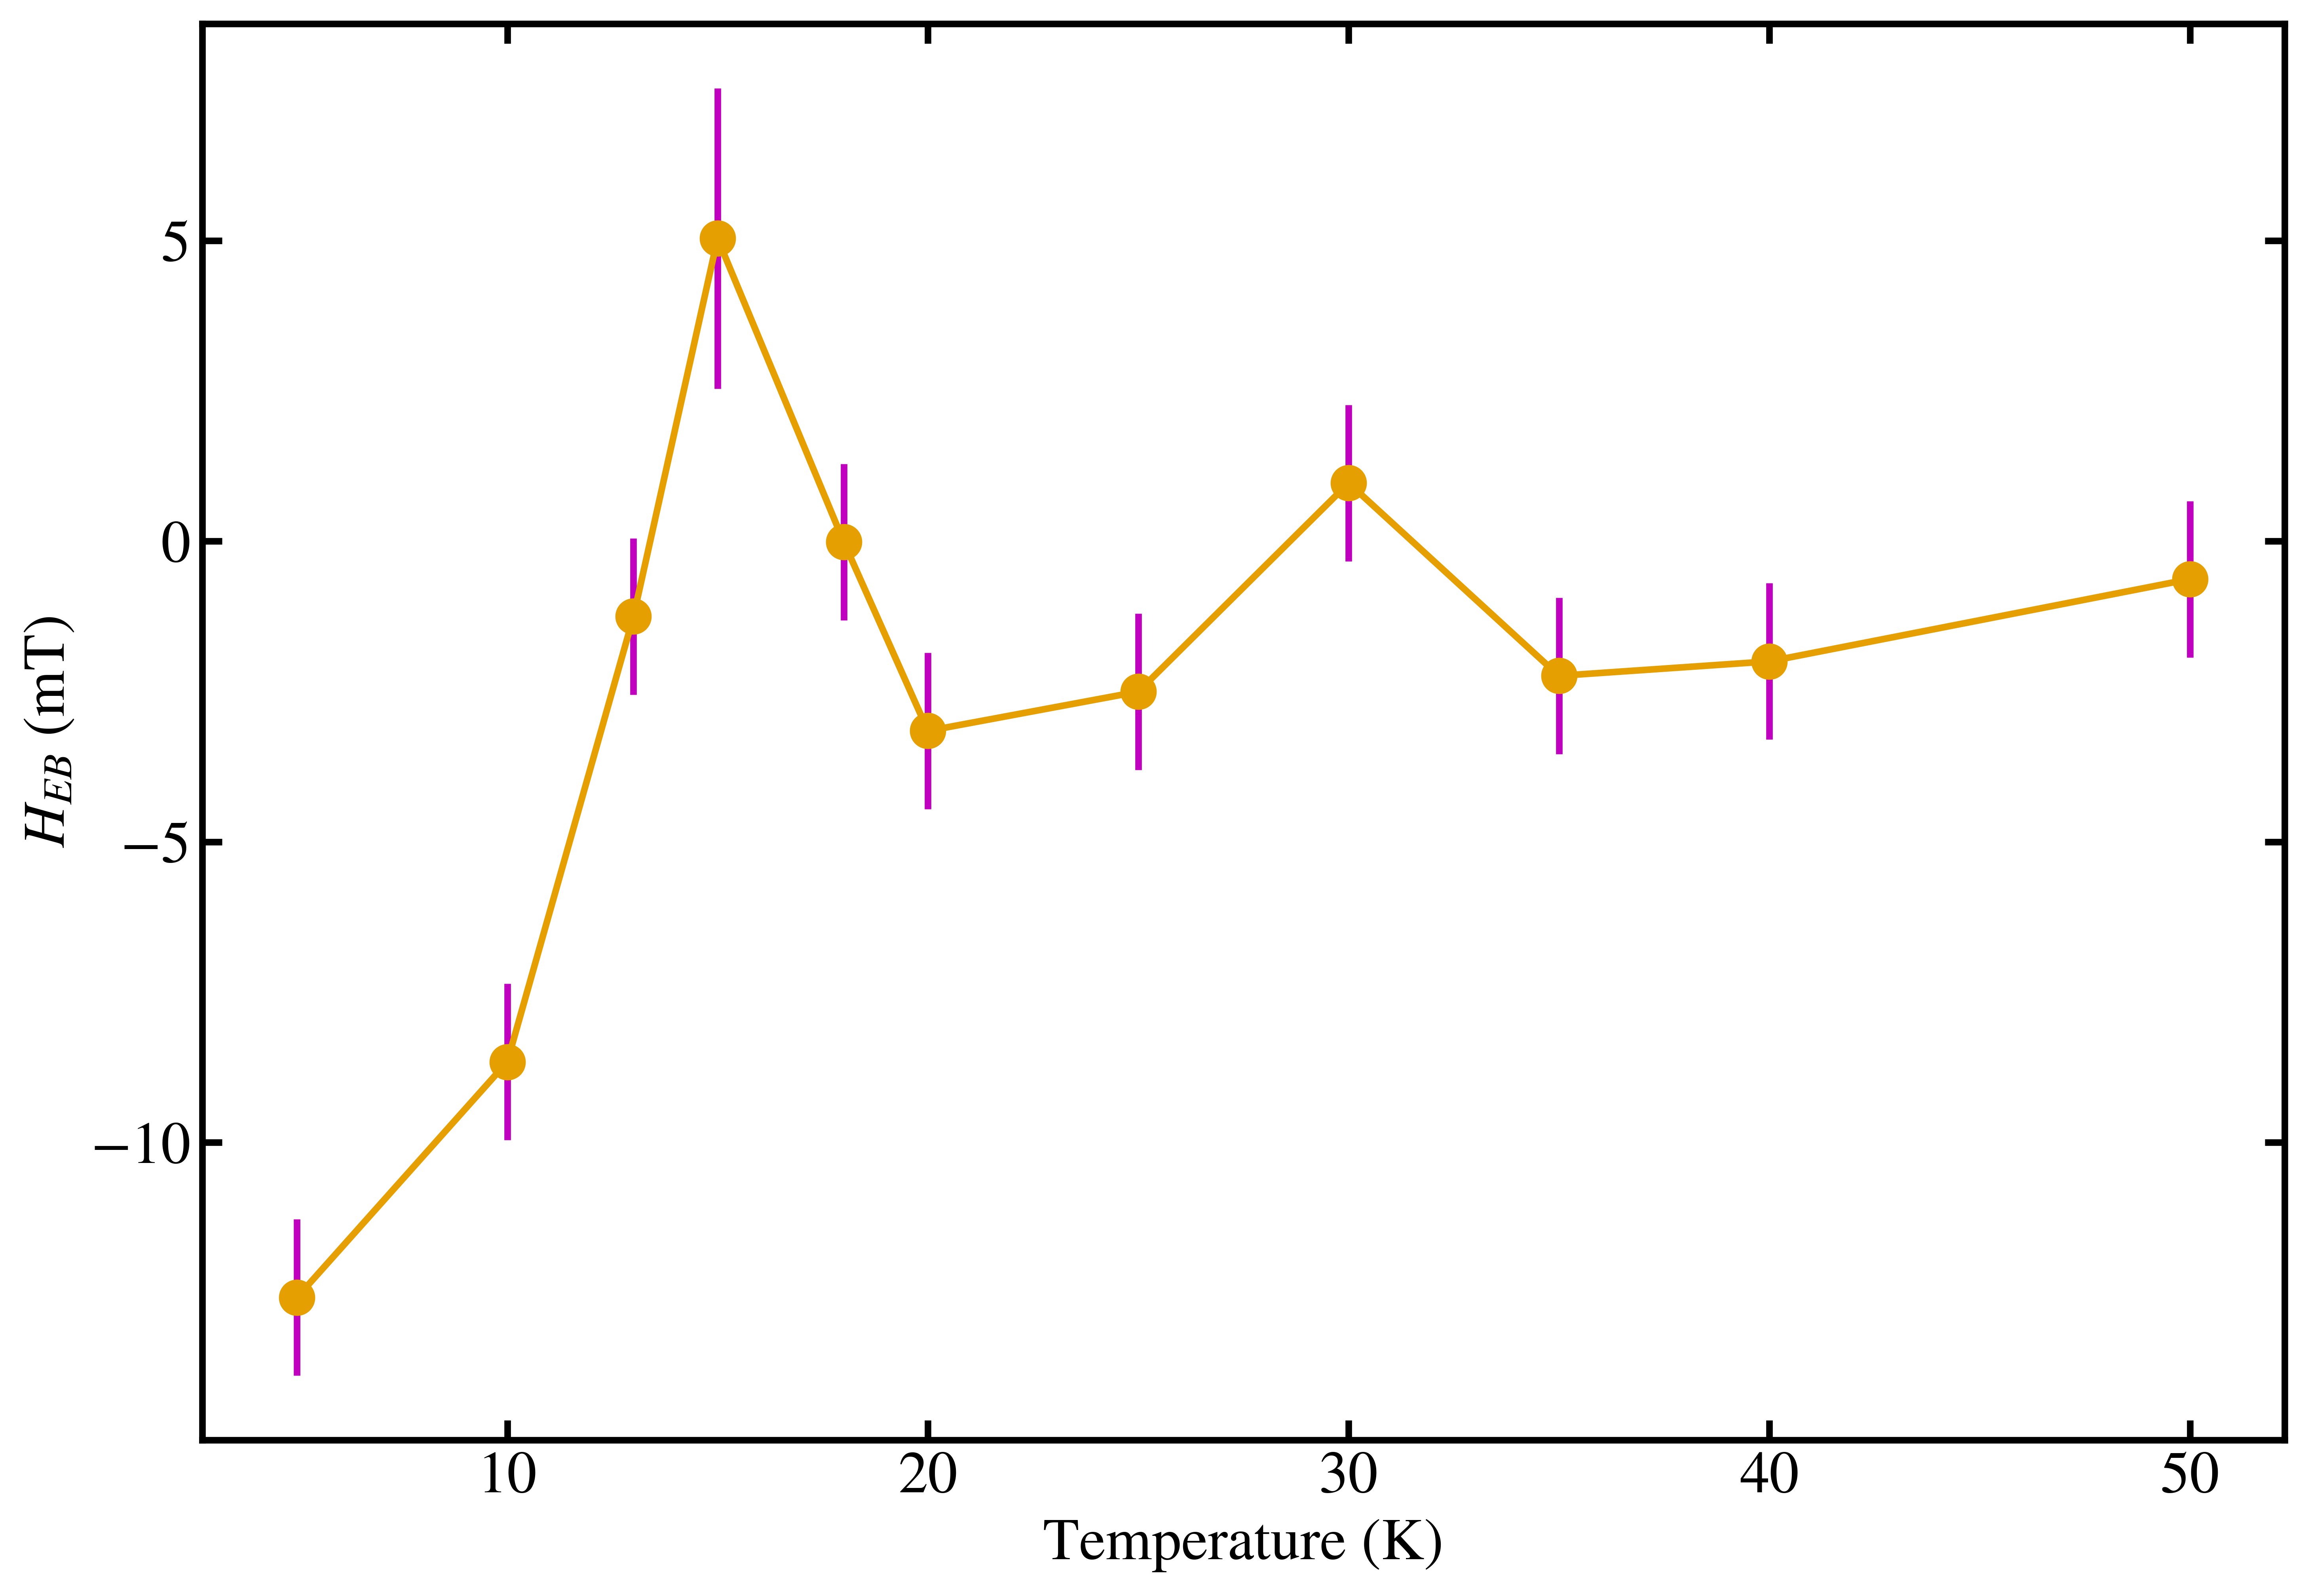

In [18]:
# F3 — H_EB vs Temperature (dpi=600)
plt.figure(dpi=600)
plt.errorbar(sorted_T_g10, sorted_HEB_g10, error_g10,
             fmt='-o', ecolor='m', markersize=10)
plt.xlabel('Temperature (K)', fontsize=18)
plt.ylabel('$H_{EB}$ (mT)', fontsize=18)
plt.tight_layout()
plt.show()

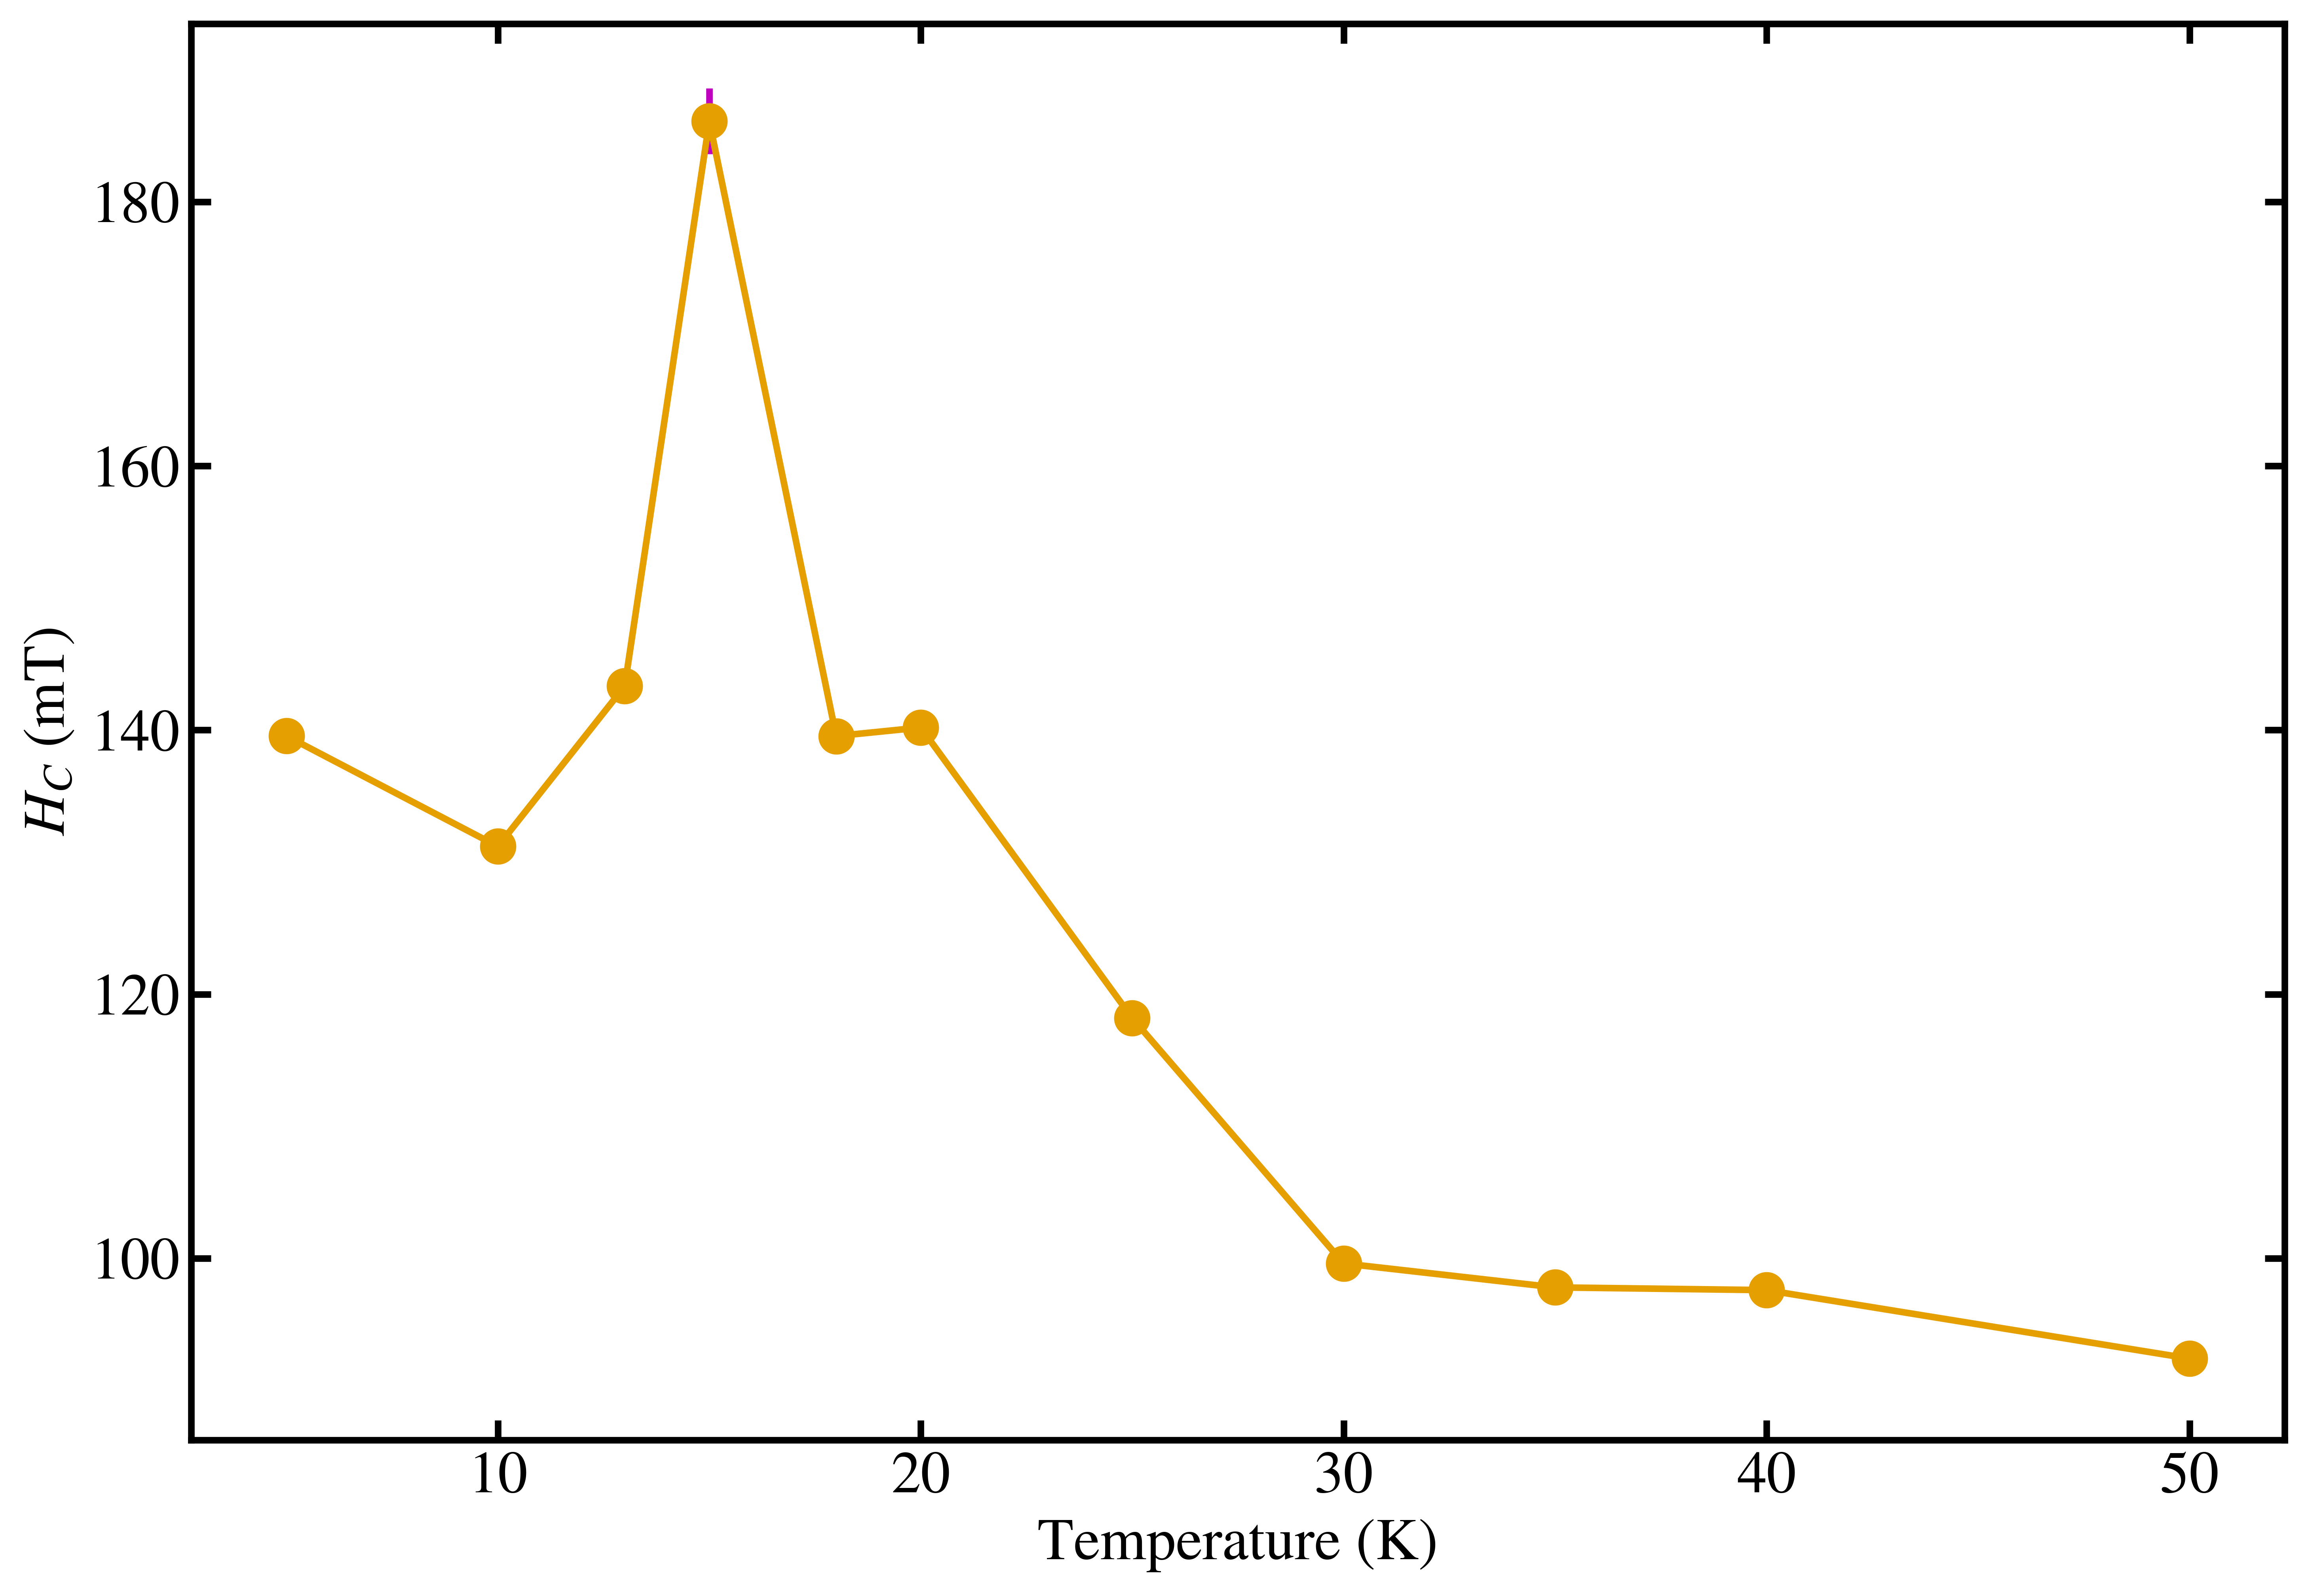

In [19]:
# F4 — H_C vs Temperature (dpi=600)
plt.figure(dpi=600)
plt.errorbar(sorted_T_g10, sorted_W_g10, error_g10,
             fmt='-o', ecolor='m', markersize=10)
plt.xlabel('Temperature (K)', fontsize=18)
plt.ylabel('$H_{C}$ (mT)', fontsize=18)
plt.tight_layout()
plt.show()

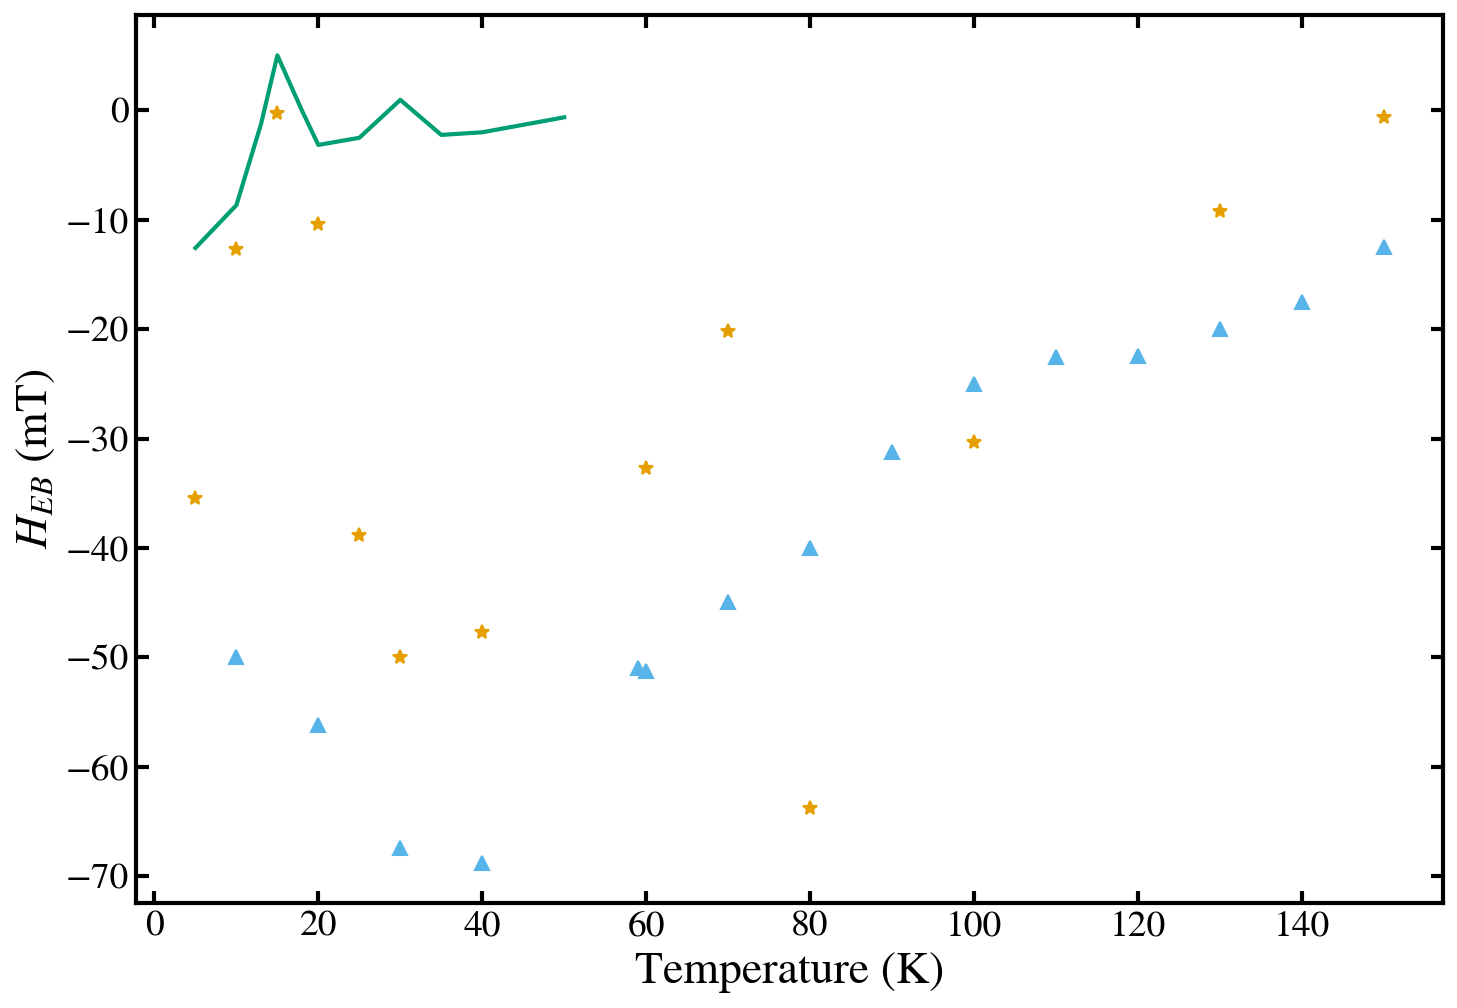

In [20]:
# F5 — 3-series H_EB comparison (no errorbars)
plt.figure()
plt.plot(sorted_T_OFGTD, sorted_HE_OFGTD, '*')
plt.plot(T_OFGT3, HE_OFGT3, '^')
plt.plot(sorted_T_g10, sorted_HEB_g10)
plt.xlabel('Temperature (K)')
plt.ylabel('$H_{EB}$ (mT)')
plt.tight_layout()
plt.show()

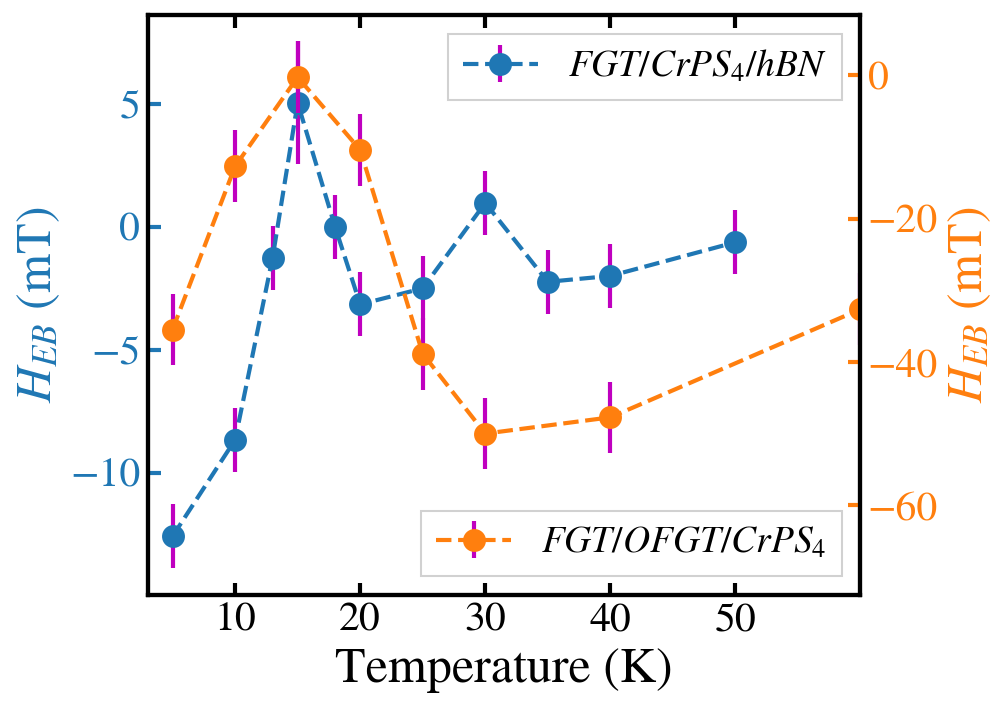

In [21]:
# F9 — Same as line-519 but figsize=(7, 5)
fig, ax1 = plt.subplots(figsize=(7, 5))
plt.xlim(3, 60)
for spine in fig.gca().spines.values():
    spine.set_linewidth(2)

ax1.errorbar(sorted_T_g10, sorted_HEB_g10, error_g10,
             fmt='--o', color='#1f77b4', ecolor='m', markersize=10)
ax1.set_xlabel('Temperature (K)', fontsize=24)
ax1.set_ylabel('$H_{EB}$ (mT)', color='#1f77b4', fontsize=24)
ax1.tick_params('y', colors='#1f77b4', labelsize=20)
ax1.tick_params('x', labelsize=20)
ax1.legend([r'$FGT/CrPS_4/hBN$'], fontsize=18)
ax1.set_xticks([10, 20, 30, 40, 50])

ax2 = ax1.twinx()
ax2.errorbar(sorted_T_OFGTD, sorted_HE_OFGTD, Error_OFGTD,
             fmt='--o', color='#ff7f0e', ecolor='m', markersize=10)
ax2.set_ylabel('$H_{EB}$ (mT)', color='#ff7f0e', fontsize=24)
ax2.legend([r'$FGT/OFGT/CrPS_4$'], loc='lower right', fontsize=18)
ax2.tick_params('y', colors='#ff7f0e', labelsize=20)
plt.xlim(3, 60)
plt.tight_layout()
plt.show()

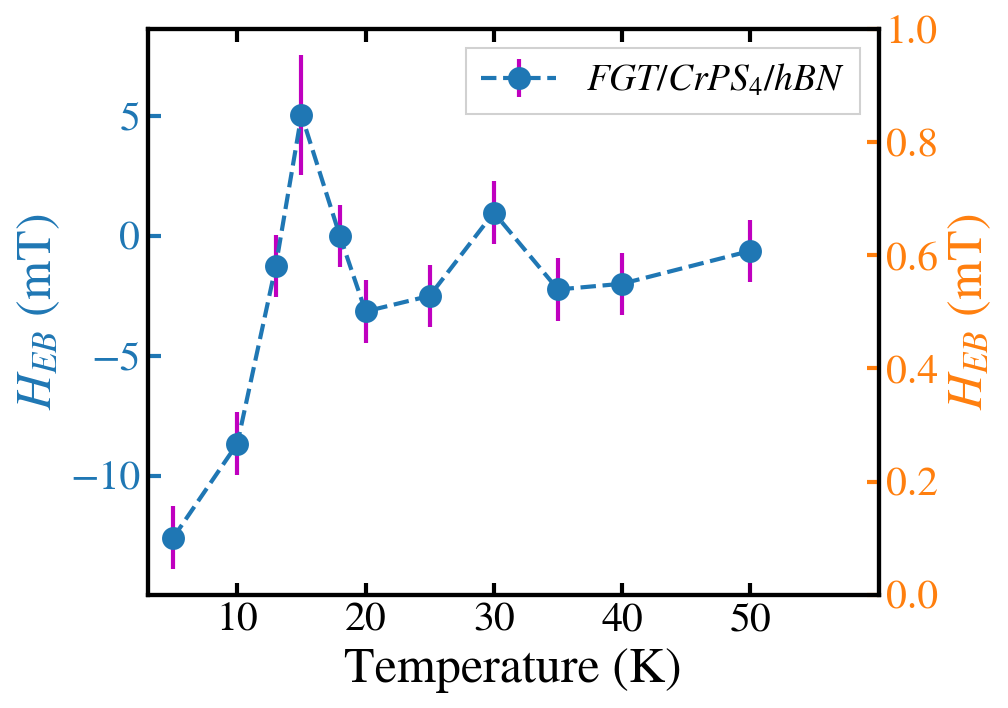

In [22]:
# F10 — Dual-axis H_EB, figsize=(7,5), no OFGT data on right axis
fig, ax1 = plt.subplots(figsize=(7, 5))
plt.xlim(3, 60)
for spine in fig.gca().spines.values():
    spine.set_linewidth(2)

ax1.errorbar(sorted_T_g10, sorted_HEB_g10, error_g10,
             fmt='--o', color='#1f77b4', ecolor='m', markersize=10)
ax1.set_xlabel('Temperature (K)', fontsize=24)
ax1.set_ylabel('$H_{EB}$ (mT)', color='#1f77b4', fontsize=24)
ax1.tick_params('y', colors='#1f77b4', labelsize=20)
ax1.tick_params('x', labelsize=20)
ax1.legend([r'$FGT/CrPS_4/hBN$'], fontsize=18)
ax1.set_xticks([10, 20, 30, 40, 50])

ax2 = ax1.twinx()
ax2.set_ylabel('$H_{EB}$ (mT)', color='#ff7f0e', fontsize=24)
ax2.tick_params('y', colors='#ff7f0e', labelsize=20)
plt.xlim(3, 60)
plt.tight_layout()
plt.show()

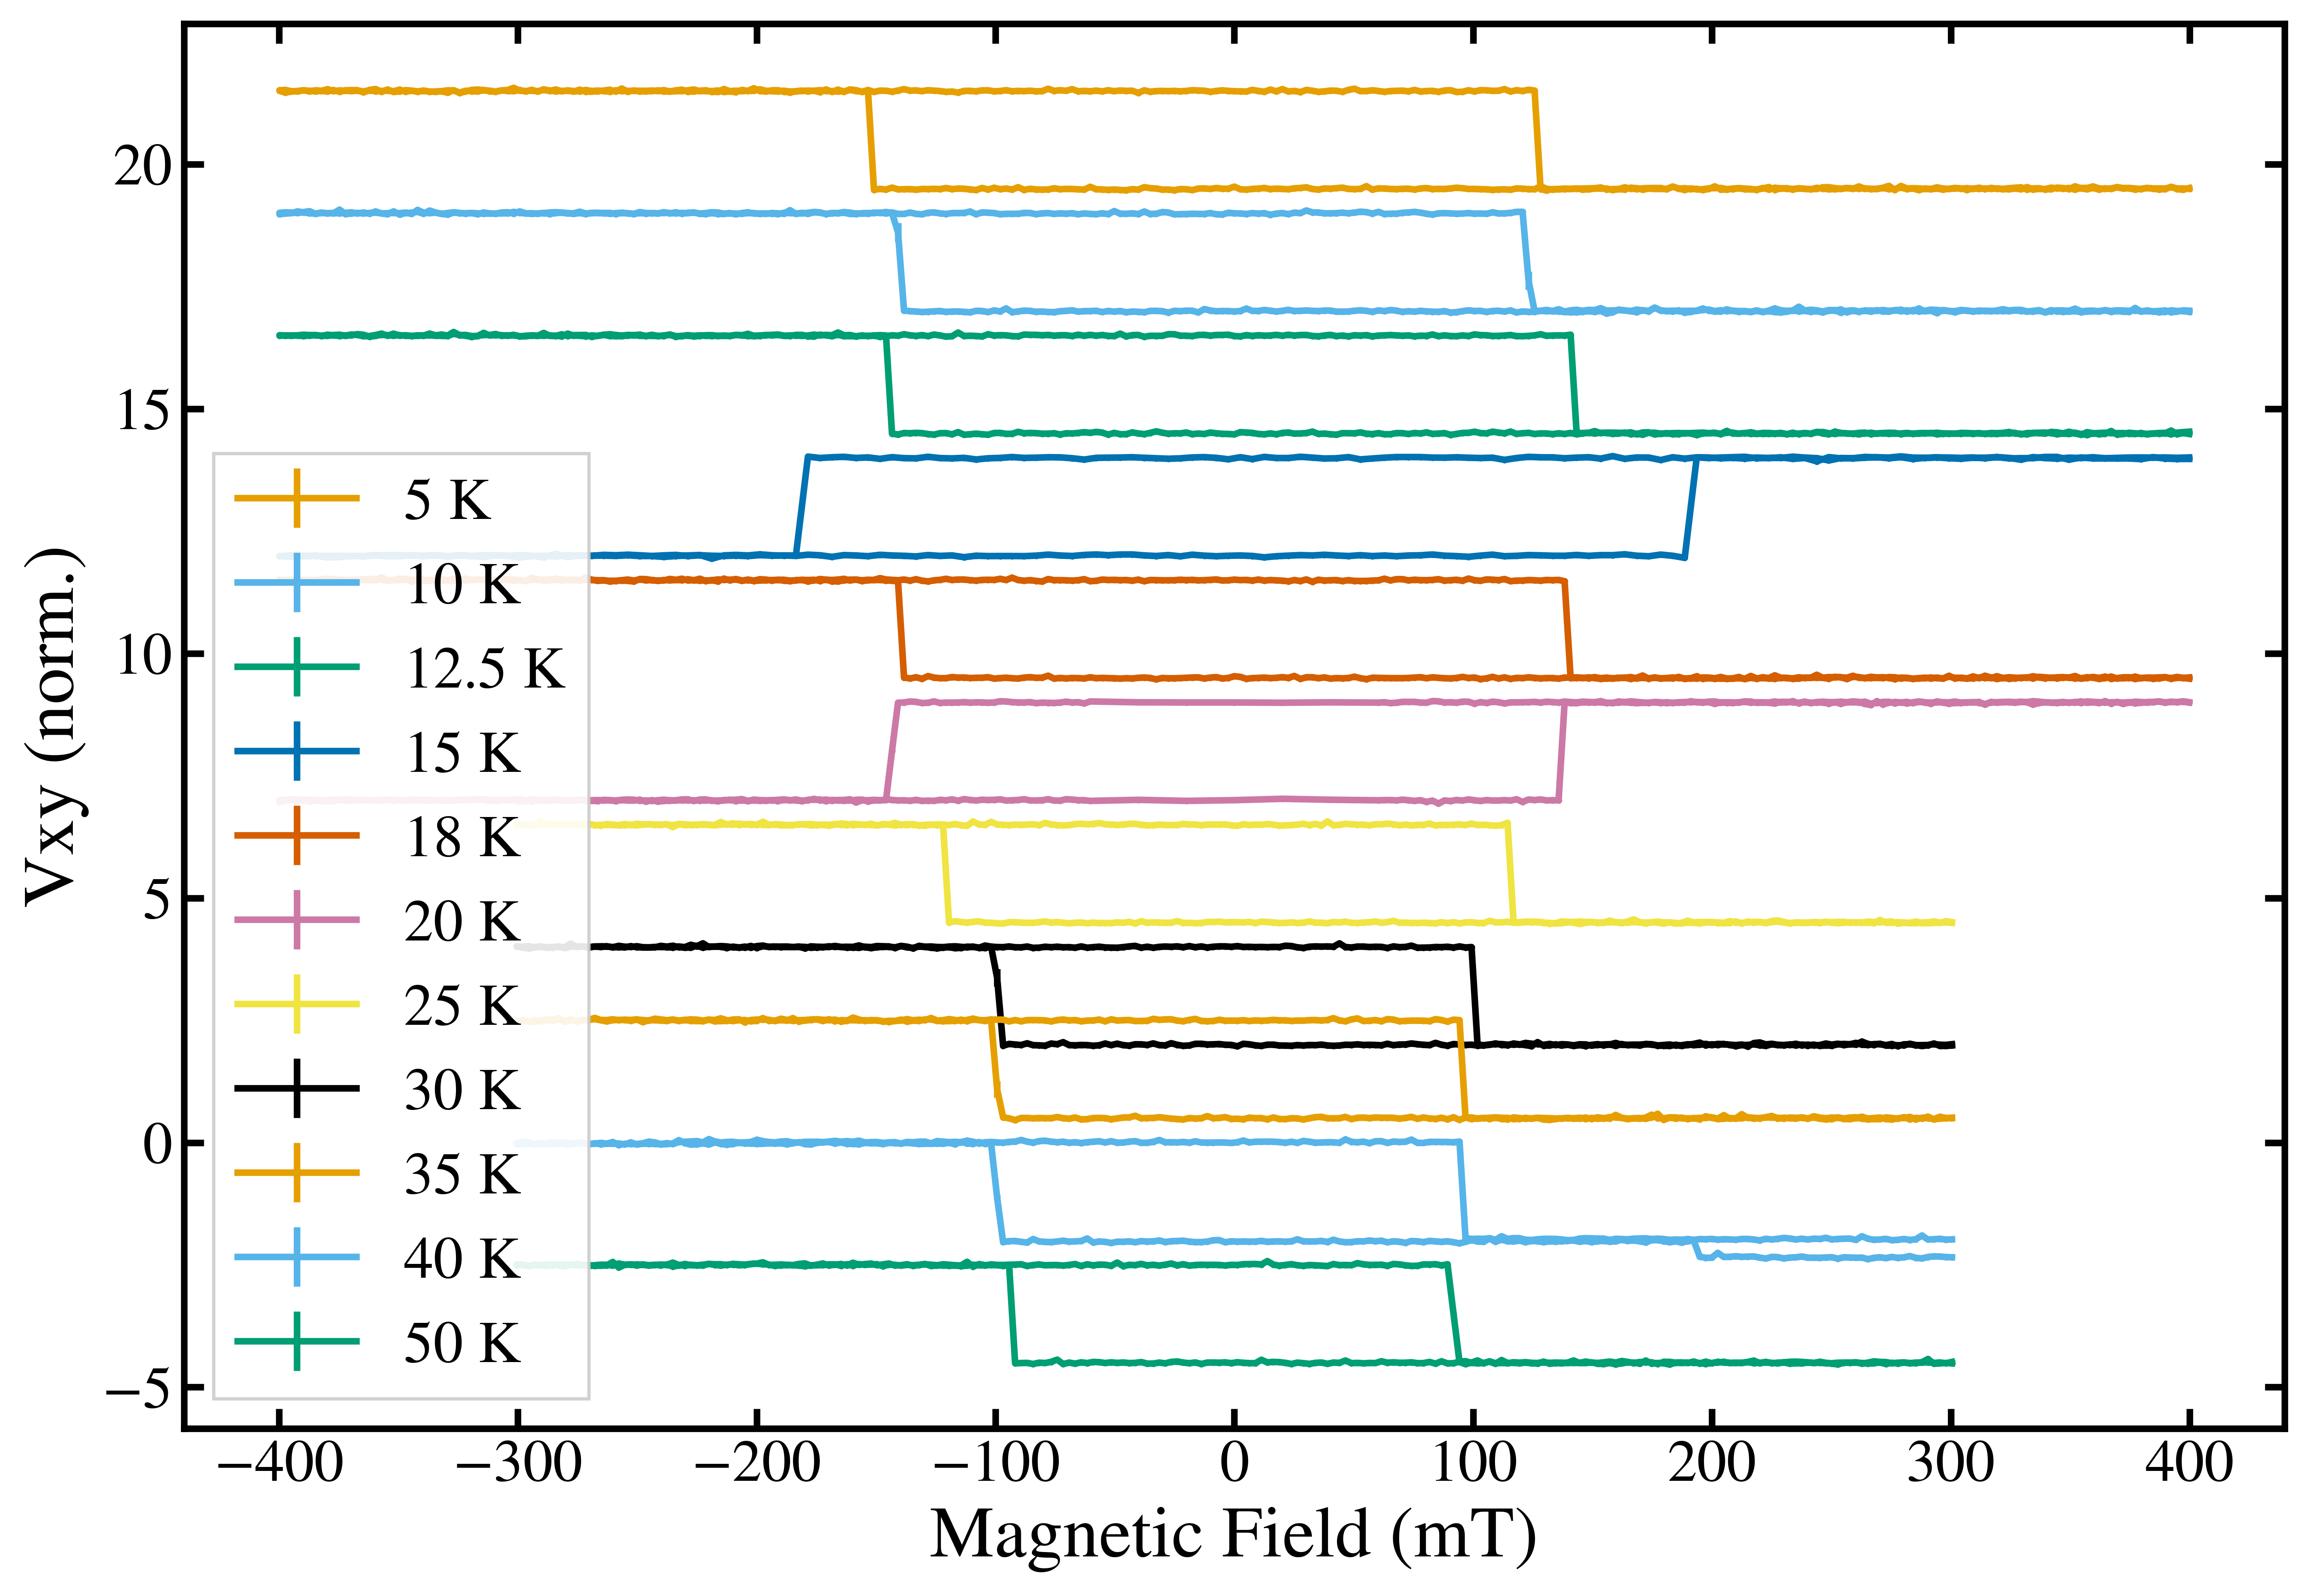

In [23]:
# F11 — Waterfall fmt='-o', mixed sign flips, 5–50 K
plt.figure(dpi=600)
plt.errorbar(Field_g10[index10(5)],   Vxy_norm_g10[index10(5)]  + 20.5, Vxy_err_g10[index10(5)],  fmt='-o', markersize=1)
plt.errorbar(Field_g10[index10(10)],  Vxy_norm_g10[index10(10)] + 18,   Vxy_err_g10[index10(10)], fmt='-o', markersize=1)
plt.errorbar(Field_g10[index10(13)],  Vxy_norm_g10[index10(13)] + 15.5, Vxy_err_g10[index10(13)], fmt='-o', markersize=1)
plt.errorbar(Field_g10[index10(15)], -Vxy_norm_g10[index10(15)] + 13,   Vxy_err_g10[index10(15)], fmt='-o', markersize=1)
plt.errorbar(Field_g10[index10(18)],  Vxy_norm_g10[index10(18)] + 10.5, Vxy_err_g10[index10(18)], fmt='-o', markersize=1)
plt.errorbar(Field_g10[index10(20)], -Vxy_norm_g10[index10(20)] + 8,    Vxy_err_g10[index10(20)], fmt='-o', markersize=1)
plt.errorbar(Field_g10[index10(25)],  Vxy_norm_g10[index10(25)] + 5.5,  Vxy_err_g10[index10(25)], fmt='-o', markersize=1)
plt.errorbar(Field_g10[index10(30)],  Vxy_norm_g10[index10(30)] + 3,    Vxy_err_g10[index10(30)], fmt='-o', markersize=1)
plt.errorbar(Field_g10[index10(35)],  Vxy_norm_g10[index10(35)] + 1.5,  Vxy_err_g10[index10(35)], fmt='-o', markersize=1)
plt.errorbar(Field_g10[index10(40)],  Vxy_norm_g10[index10(40)] - 1,    Vxy_err_g10[index10(40)], fmt='-o', markersize=1)
plt.errorbar(Field_g10[index10(50)],  Vxy_norm_g10[index10(50)] - 3.5,  Vxy_err_g10[index10(50)], fmt='-o', markersize=1)
plt.legend(['5 K', '10 K', '12.5 K', '15 K', '18 K', '20 K',
            '25 K', '30 K', '35 K', '40 K', '50 K'])
plt.xlabel('Magnetic Field (mT)')
plt.ylabel('Vxy (norm.)')
plt.tight_layout()
plt.show()

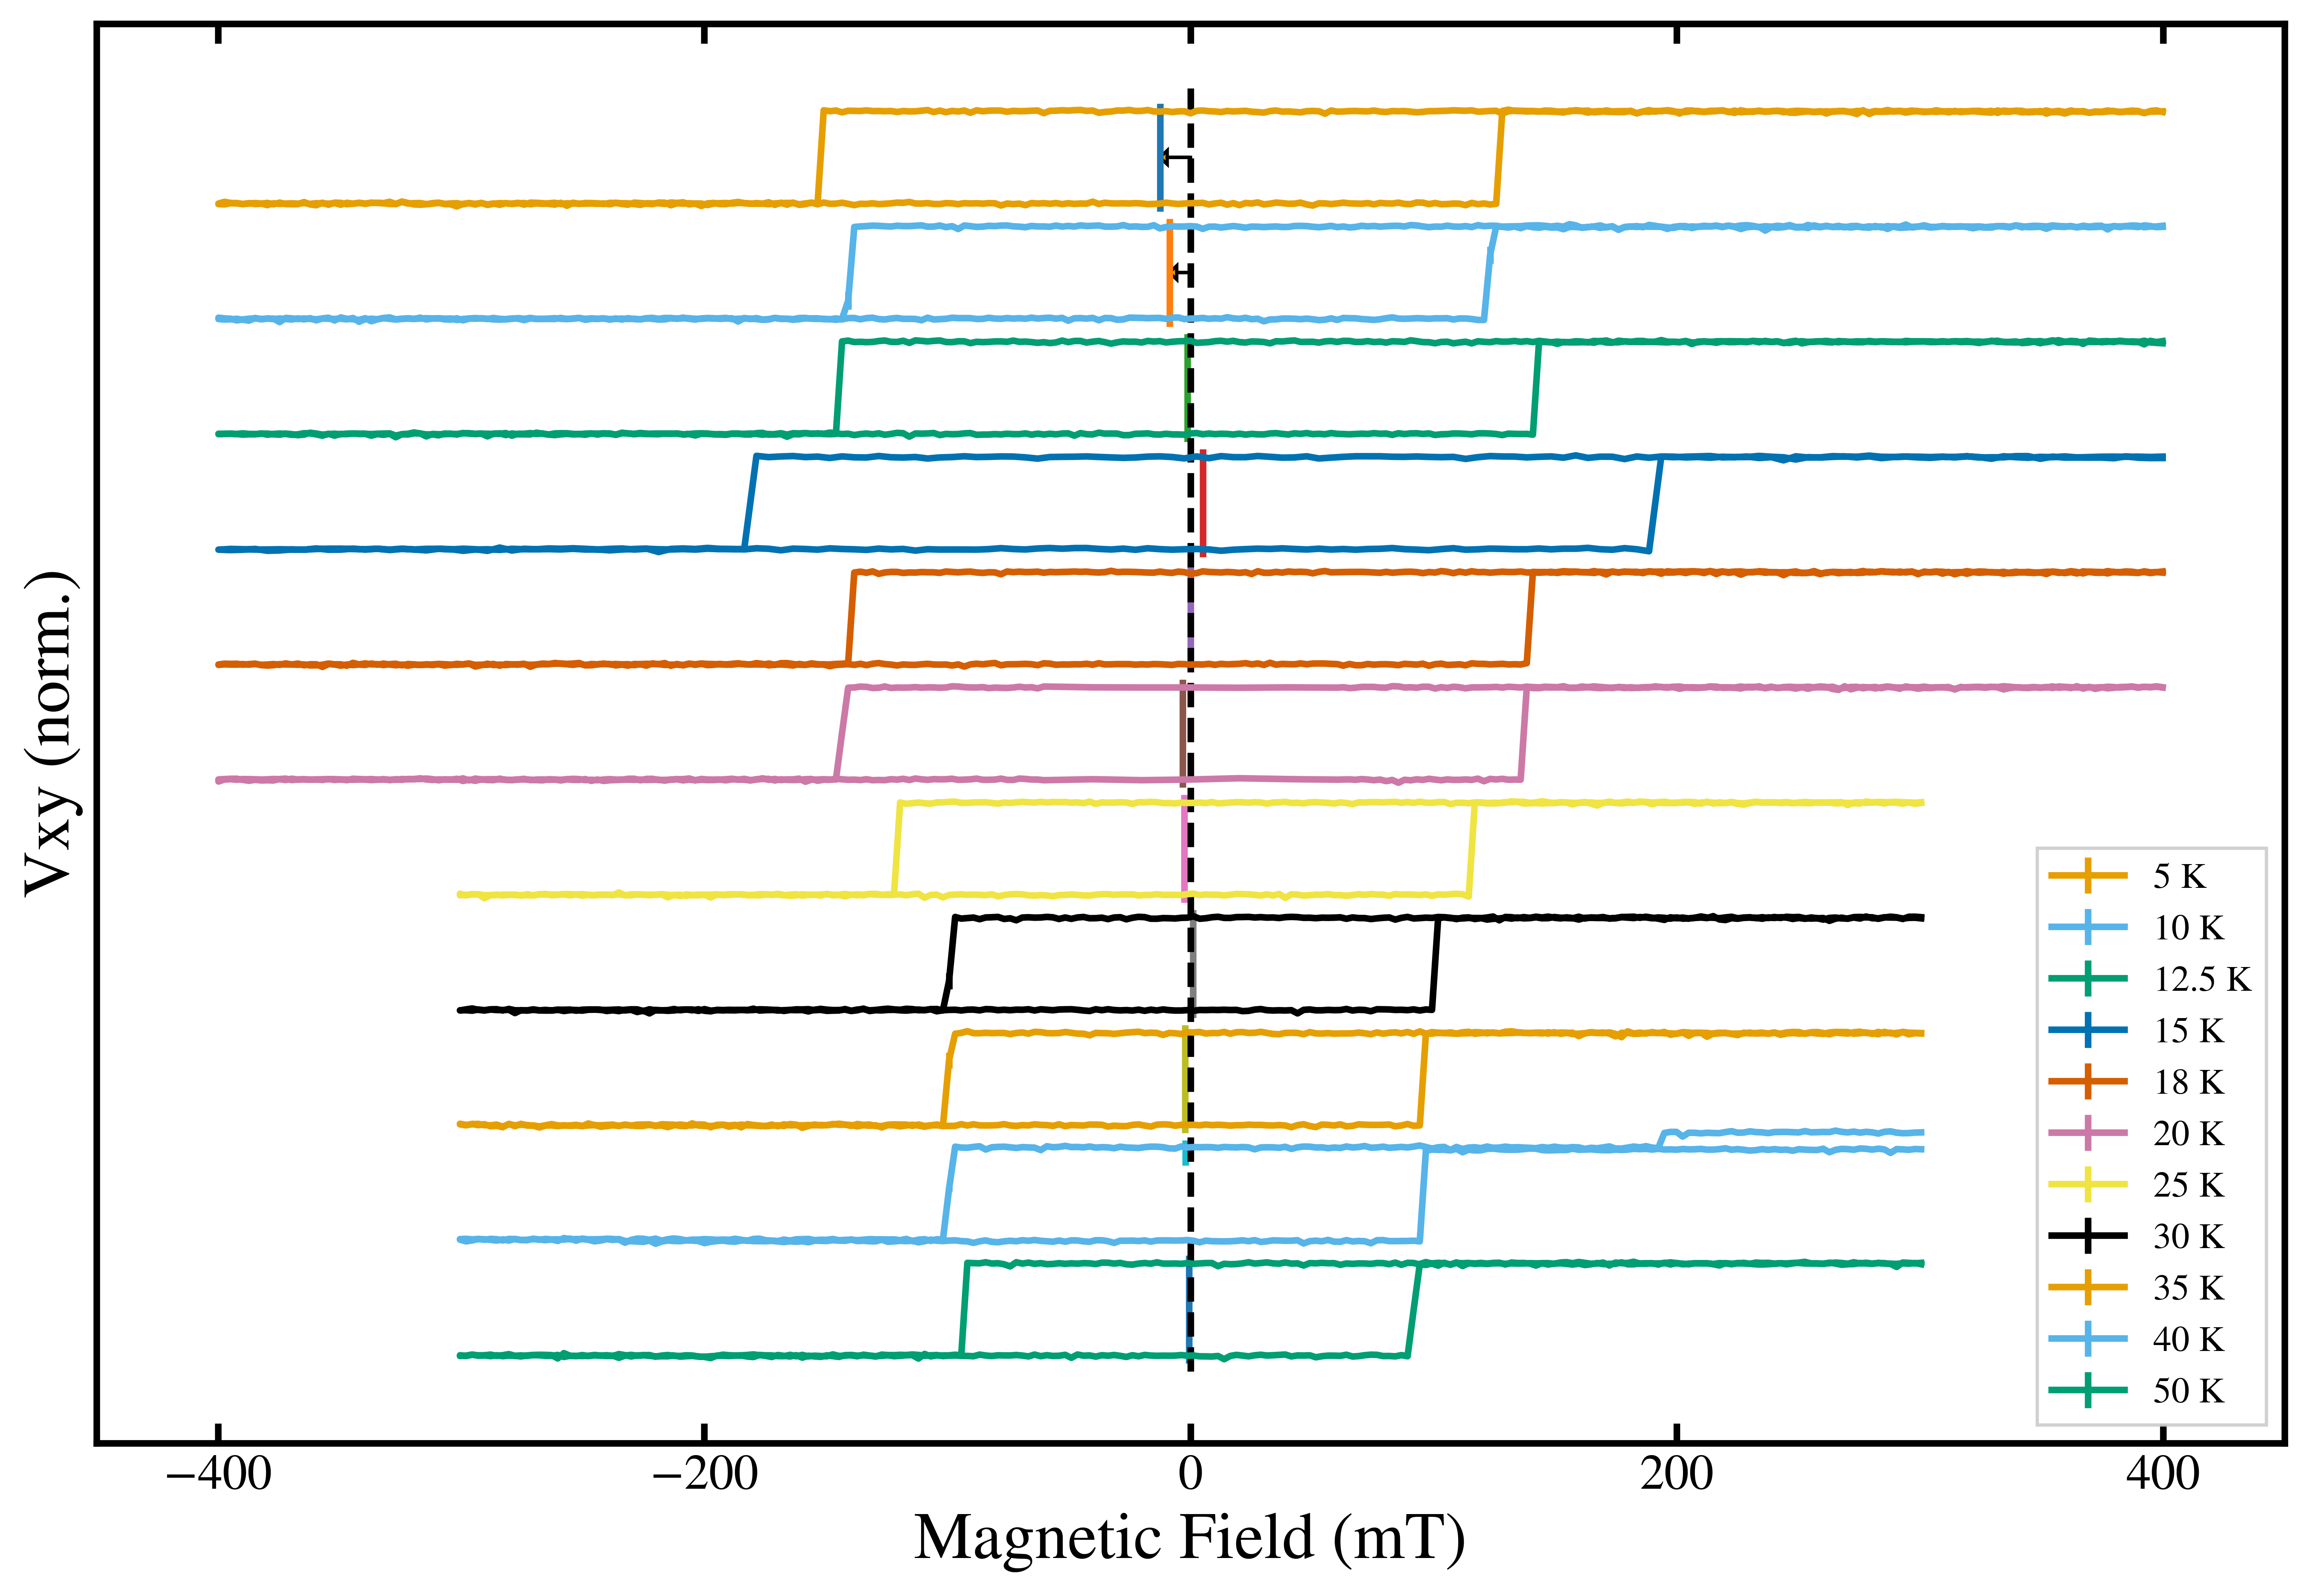

In [24]:
# F12 — Waterfall fmt='-', ALL temperatures sign-flipped, HEB tick marks, arrows at 5K/10K
plt.figure(dpi=600)
plt.errorbar(Field_g10[index10(5)],  -Vxy_norm_g10[index10(5)]  + 20.5, Vxy_err_g10[index10(5)],  fmt='-', markersize=1)
plt.errorbar(Field_g10[index10(10)], -Vxy_norm_g10[index10(10)] + 18,   Vxy_err_g10[index10(10)], fmt='-', markersize=1)
plt.errorbar(Field_g10[index10(13)], -Vxy_norm_g10[index10(13)] + 15.5, Vxy_err_g10[index10(13)], fmt='-', markersize=1)
plt.errorbar(Field_g10[index10(15)], -Vxy_norm_g10[index10(15)] + 13,   Vxy_err_g10[index10(15)], fmt='-', markersize=1)
plt.errorbar(Field_g10[index10(18)], -Vxy_norm_g10[index10(18)] + 10.5, Vxy_err_g10[index10(18)], fmt='-', markersize=1)
plt.errorbar(Field_g10[index10(20)], -Vxy_norm_g10[index10(20)] + 8,    Vxy_err_g10[index10(20)], fmt='-', markersize=1)
plt.errorbar(Field_g10[index10(25)], -Vxy_norm_g10[index10(25)] + 5.5,  Vxy_err_g10[index10(25)], fmt='-', markersize=1)
plt.errorbar(Field_g10[index10(30)], -Vxy_norm_g10[index10(30)] + 3,    Vxy_err_g10[index10(30)], fmt='-', markersize=1)
plt.errorbar(Field_g10[index10(35)], -Vxy_norm_g10[index10(35)] + 0.5,  Vxy_err_g10[index10(35)], fmt='-', markersize=1)
plt.errorbar(Field_g10[index10(40)], -Vxy_norm_g10[index10(40)] - 2,    Vxy_err_g10[index10(40)], fmt='-', markersize=1)
plt.errorbar(Field_g10[index10(50)], -Vxy_norm_g10[index10(50)] - 4.5,  Vxy_err_g10[index10(50)], fmt='-', markersize=1)

plt.legend(['5 K', '10 K', '12.5 K', '15 K', '18 K', '20 K',
            '25 K', '30 K', '35 K', '40 K', '50 K'],
           loc='lower right', fontsize=11)

# HEB tick marks at each temperature
plt.plot([HEB_g10[index10(5)],  HEB_g10[index10(5)]],  [21.6,  21.6 - 2.2], '-', color='#1f77b4')
plt.plot([HEB_g10[index10(10)], HEB_g10[index10(10)]], [19.1,  19.1 - 2.2], '-', color='#ff7f0e')
plt.plot([HEB_g10[index10(13)], HEB_g10[index10(13)]], [16.6,  16.6 - 2.2], '-', color='#2ca02c')
plt.plot([HEB_g10[index10(15)], HEB_g10[index10(15)]], [14.1,  14.1 - 2.2], '-', color='#d62728')
plt.plot([HEB_g10[index10(18)], HEB_g10[index10(18)]], [11.6,  11.6 - 2.2], '-', color='#9467bd')
plt.plot([HEB_g10[index10(20)], HEB_g10[index10(20)]], [9.1,   9.1  - 2.2], '-', color='#8c564b')
plt.plot([HEB_g10[index10(25)], HEB_g10[index10(25)]], [6.6,   6.6  - 2.2], '-', color='#e377c2')
plt.plot([HEB_g10[index10(30)], HEB_g10[index10(30)]], [4.1,   4.1  - 2.2], '-', color='#7f7f7f')
plt.plot([HEB_g10[index10(35)], HEB_g10[index10(35)]], [1.6,   1.6  - 2.2], '-', color='#bcbd22')
plt.plot([HEB_g10[index10(40)], HEB_g10[index10(40)]], [-0.9,  0.9  - 2.2], '-', color='#17becf')
plt.plot([HEB_g10[index10(50)], HEB_g10[index10(50)]], [-3.4, -3.4  - 2.2], '-', color='#1f77b4')

# Arrows at 5K and 10K only (15K commented out in original)
plt.arrow(0, 20.5,  HEB_g10[index10(5)],  0,
          head_width=0.3, head_length=3, length_includes_head=True)
plt.arrow(0, 18.0,  HEB_g10[index10(10)], 0,
          head_width=0.3, head_length=3, length_includes_head=True)
# plt.arrow(0, 13, HEB_g10[index10(15)], 0, head_width=0.3, head_length=3, length_includes_head=True)

plt.plot([0, 0], [22, -6], '--', color='k')
plt.xlabel('Magnetic Field (mT)', fontsize=20)
plt.ylabel('Vxy (norm.)', fontsize=20)
plt.xticks([-400, -200, 0, 200, 400], fontsize=15)
plt.yticks([])
plt.xlim(-450, 450)
plt.tight_layout()
plt.show()